Section 1:
Toy Examples for Exploration

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import iisignature
import faiss

corpus: (10000, 100) - truncation level 5


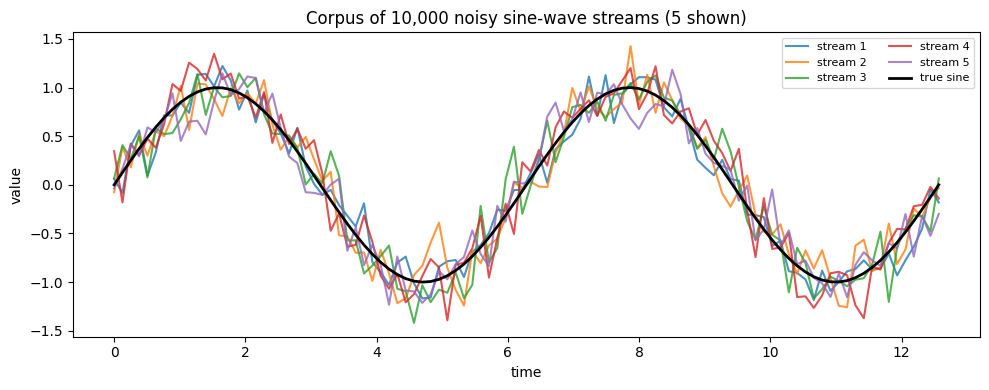

In [2]:
#Create a corpus of noisy sine-wave streams
rng = np.random.default_rng(42)
n_streams = 10000
length = 100
t = np.linspace(0, 4 * np.pi, length)
base_signal = np.sin(t)

# Noise level shared by the corpus and by every toy stream in the next cell. Held in one
# variable so the two cannot drift apart: an earlier version had the corpus at 0.2 while
# five of the six toy streams used 0.15, which made every test stream systematically
# smoother than the corpus it was scored against. That biases towards false negatives - a
# cleaner-than-corpus stream sits near the corpus mean, so its nearest-neighbour distance
# is small and it passes - and it left `no_anomaly` an easier-than-typical stream rather
# than an honest negative control.
CORPUS_NOISE = 0.2

corpus = base_signal[None, :] + rng.normal(0, CORPUS_NOISE, size=(n_streams, length))

# Signature truncation level. Used from Section 3 onward; set here so the one knob that
# controls signature dimension throughout the notebook lives with the data it describes.
TRUNC = 5

print('corpus:', corpus.shape, '- truncation level', TRUNC)

# Visualize a few example streams
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.plot(t, corpus[i], alpha=0.8, label=f"stream {i+1}")
plt.plot(t, base_signal, color="black", linewidth=2, label="true sine")
plt.xlabel("time")
plt.ylabel("value")
plt.title(f"Corpus of {n_streams:,} noisy sine-wave streams (5 shown)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [3]:
# Combine all anomaly examples into one DataFrame.
# Each stream gets its own seeded generator so it is reproducible independently of the
# order the cells above were run in.
#
# All of them draw at CORPUS_NOISE, so each toy stream is the corpus's own signal plus
# the corpus's own noise, perturbed only by its named anomaly. `no_anomaly` is then a
# genuine draw from the corpus distribution, which is what makes it a usable negative
# control rather than just a quiet stream.
rng_spike = np.random.default_rng(7)
rng_shift = np.random.default_rng(8)
rng_drift = np.random.default_rng(9)
rng_freq = np.random.default_rng(10)
rng_clean = np.random.default_rng(11)

# The toy streams reuse the corpus's own time grid `t` from Section 1. anomaly_window
# and pysegments_anomaly_detector both locate the corpus window by time rather than by
# index, so matching grids are not required - but in this notebook the two do coincide.

spike_signal = np.sin(t) + rng_spike.normal(0, CORPUS_NOISE, size=len(t))
spike_index = np.abs(t - (np.pi / 2)).argmin()
spike_signal[spike_index] += 3.0

level_shift_signal = np.sin(t) + rng_shift.normal(0, CORPUS_NOISE, size=len(t))
shift_start = np.where(t > np.pi)[0][0]
level_shift_signal[shift_start:] += 2.0

drift_signal = t + np.sin(t) + rng_drift.normal(0, CORPUS_NOISE, size=len(t))

freq_signal = np.sin(2 * t) + rng_freq.normal(0, CORPUS_NOISE, size=len(t))

multi_spike_signal = np.sin(t) + rng_spike.normal(0, CORPUS_NOISE, size=len(t))
multi_spike_signal[spike_index] += 3.0
multi_spike_index = np.abs(t - (3 * np.pi / 2)).argmin()
multi_spike_signal[multi_spike_index] += 3.0
multi_spike_index2 = np.abs(t - (5 * np.pi / 2)).argmin()
multi_spike_signal[multi_spike_index2] += 3.0

no_anomaly_signal = np.sin(t) + rng_clean.normal(0, CORPUS_NOISE, size=len(t))

frames = [
    pd.DataFrame({'time': t, 'output': spike_signal, 'anomaly_type': 'spike'}),
    pd.DataFrame({'time': t, 'output': level_shift_signal, 'anomaly_type': 'level_shift'}),
    pd.DataFrame({'time': t, 'output': drift_signal, 'anomaly_type': 'upward_drift'}),
    pd.DataFrame({'time': t, 'output': freq_signal, 'anomaly_type': 'doubled_frequency'}),
    pd.DataFrame({'time': t, 'output': no_anomaly_signal, 'anomaly_type': 'no_anomaly'}),
    pd.DataFrame({'time': t, 'output': multi_spike_signal, 'anomaly_type': 'multi_spike'})
]

toy_anomalies = pd.concat(frames, ignore_index=True)

print(toy_anomalies.head())
print(toy_anomalies.tail())
print(toy_anomalies.shape)

       time    output anomaly_type
0  0.000000  0.000246        spike
1  0.126933  0.186342        spike
2  0.253866  0.196320        spike
3  0.380799  0.193544        spike
4  0.507732  0.395263        spike
          time    output anomaly_type
595  12.058638 -0.329908  multi_spike
596  12.185572 -0.205426  multi_spike
597  12.312505 -0.066871  multi_spike
598  12.439438 -0.217716  multi_spike
599  12.566371  0.302995  multi_spike
(600, 3)


Section 2: Implementing the transforms and KNN

In [4]:
#Mahalanobis distance helper functions
def build_covariance_matrix(X, rcond=1e-12):
    """Build the Mahalanobis whitening matrix for a set of signature vectors.

    Returns Sigma^{-1/2}, the symmetric matrix square root of the (pseudo-)inverse
    covariance, so that the plain Euclidean distance between whitened vectors is the
    Mahalanobis distance:

        ||W(x - y)||^2  =  (x - y)^T W^T W (x - y)  =  (x - y)^T Sigma^{-1} (x - y)

    since W = W^T and W^2 = Sigma^{-1}.

    This deliberately differs from upstream SigNova.py's `build_covariance_matrix`, which
    returns Sigma^{-1} itself and then applies it directly to the differences - giving
    (x - y)^T Sigma^{-2} (x - y), i.e. the Mahalanobis distance with every direction's
    weight squared. That over-weights low-variance directions quadratically, which matters
    enormously here because signature terms span many orders of magnitude (a level-k term
    scales like (path length)^k, so at TRUNC=5 the largest and smallest terms of a single
    vector differ by 1e10 or more). On a synthetic ill-conditioned example the two formulas
    disagree by a factor of ~5e9; in Section 5 the difference is the difference between
    missing `spike` and `doubled_frequency` entirely and localizing both.

    Directions whose singular value is negligible relative to the largest are dropped
    (`rcond`), matching what np.linalg.pinv does internally - without this the whitening
    would divide by numerical noise in the corpus's null directions.
    """
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0)
    X_centered = X - mu
    n, D = X_centered.shape

    # Sigma = V diag(s^2 / n) V^T, so Sigma^{-1/2} = V diag(sqrt(n) / s) V^T.
    #
    # For tall matrices, take a QR first: R is (D, D) and carries exactly the same singular
    # values and right singular vectors as X_centered, so this is the same answer without
    # ever forming the (n, D) left factor. That matters for Section 6, which whitens pooled
    # corpora of ~700,000 rows. Note this is NOT the same as eigendecomposing X^T X, which
    # would square an already-brutal condition number; QR is backward stable.
    if n > D:
        R = np.linalg.qr(X_centered, mode='r')
        _, s, Vt = np.linalg.svd(R, full_matrices=False)
    else:
        _, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

    scale = np.zeros_like(s)
    if s.size and s.max() > 0:
        keep = s > rcond * s.max()
        scale[keep] = np.sqrt(n) / s[keep]

    return (Vt.T * scale) @ Vt


def transform_signatures(signatures, L_inv):
    """Apply the Mahalanobis whitening transform to signature vectors."""
    signatures = np.asarray(signatures, dtype=float)
    if signatures.ndim == 1:
        signatures = signatures[None, :]
    return signatures @ L_inv.T


def mKNN(signatures, L_inv, corpus_signatures, k=5):
    """Use FAISS to compute the nearest-neighbor distances after Mahalanobis whitening.

    Returns the *squared* Mahalanobis distance to the nearest corpus neighbour, since
    faiss.IndexFlatL2 reports squared L2 - matching upstream SigNova's `variance_score`,
    which likewise returns `norm_square_V`. Squaring is monotone, so every threshold
    comparison downstream is unaffected; only the units differ.

    Centering is intentionally omitted: mKNN only ever measures distances *between*
    signature vectors, and a shared mean cancels out of any difference.
    """
    X = transform_signatures(signatures, L_inv)
    X_corpus = transform_signatures(corpus_signatures, L_inv)

    X = np.asarray(X, dtype='float32')
    X_corpus = np.asarray(X_corpus, dtype='float32')

    index = faiss.IndexFlatL2(X.shape[1])
    index.add(X_corpus)
    distances, _ = index.search(X, k)

    return distances[:, 0]

Section 4: Localizing anomalies across all toy examples

`anomaly_window` splits a single stream into `n_windows` contiguous windows by time and flags each one independently. For that window's time range, `base_corpus` is sliced to the same range, a covariance matrix is built from that windowed corpus, it's split 95/5 into a training set and held-out inliers, and the threshold is the 95th percentile of inliers' Mahalanobis nearest-neighbour distance to training. The stream's own signature over that window is then scored against training and flagged if it exceeds the threshold. Returned intervals match `SigNova._flag`'s own `(start, end)` convention.

Two details worth stating precisely, since both are easy to get wrong:

- **The corpus window is located by time, not by index.** Signature magnitude depends on the path and duration covered, not on point density, so the corpus and the stream under test are not required to share a sampling grid. In this notebook they happen to — both are `linspace(0, 4*pi, 100)` — so the distinction doesn't bite here, but the machinery doesn't assume it.
- **The threshold is a percentile, not a maximum.** Upstream `calibrate_threshold` uses the max of the inlier distances; that's a single noisy sample and easily inflated by one unlucky inlier, which in practice pushes the threshold so high that almost nothing is ever flagged. A percentile stays representative of the inlier distribution as a whole, and matches what Section 5's `pysegments_anomaly_detector` and SigNova's own distfit calibration do.

Run here against every stream in `toy_anomalies`, using the Section 1 sine corpus as the reference.

In [5]:
#=================================================================================================================================
# Per-window anomaly localization: calibrate_threshold's train/inliers recipe, re-run
# per window against a base corpus restricted to that window's own time range
#=================================================================================================================================

def anomaly_window(stream, stream_time, base_corpus, base_corpus_time, n_windows,
                    trunc=2, test_size=0.05, threshold_percentile=95, random_state=None):
    """Split `stream` into `n_windows` contiguous windows by time, and flag each one
    anomalous by comparing it to a per-window reference corpus and threshold built from
    `base_corpus` restricted to that same time window.

    Per window:

    1. `base_corpus` is sliced to the points falling in the window's time range, located
       independently in `base_corpus_time` - so the corpus and the stream need not share
       a sampling grid.
    2. A base point at the origin is adjoined to the front of every path, the window's own
       and every corpus stream's, before signing. A raw signature is built from increments
       alone and so is exactly translation-invariant: two windows with identical shape but
       different absolute level produce identical signatures, which is precisely why a level
       shift would otherwise be invisible. Anchoring to a fixed external point breaks that
       invariance, making each path's absolute height part of its signature.
    3. A covariance matrix is built from the whole windowed, base-pointed corpus (matching
       `calibrate_threshold`'s convention of fitting before any split), which is then split
       randomly into a training set and a held-out inliers set of size `test_size`.
    4. The threshold is the `threshold_percentile`-th percentile of the inliers' Mahalanobis
       nearest-neighbour distance to training - not the max, which is one noisy sample and
       easily inflated (see the Section 4 preamble).
    5. `stream`'s own base-pointed signature over the window is scored against training, and
       the window is flagged if its distance exceeds the threshold.

    Parameters
    ----------
    stream : array-like, shape (length,) or (length, width)
        The single path being searched for anomalies.
    stream_time : array-like, shape (length,)
        Time coordinate for each point of `stream`.
    base_corpus : array-like, shape (n_corpus, corpus_length) or (n_corpus, corpus_length, width)
        Reference corpus of presumably-clean streams.
    base_corpus_time : array-like, shape (corpus_length,)
        Time coordinate shared by every stream in `base_corpus`.
    n_windows : int
        Number of contiguous, equal-duration windows to split the stream's time range into.
    trunc : int
        Signature truncation level.
    test_size : float
        Fraction of the windowed base corpus held out as inliers for calibrating each
        window's threshold. Default 0.05 (95/5 split), matching `calibrate_threshold`.
    threshold_percentile : float
        Percentile of inlier distances used as each window's threshold. Default 95.
    random_state : int or None
        Seed for the train/inliers split.

    Returns
    -------
    list of (float, float)
        (start_time, end_time) of every window flagged anomalous.
    """
    stream_values = np.asarray(stream, dtype=float)
    if stream_values.ndim == 1:
        stream_values = stream_values[:, None]
    stream_time = np.asarray(stream_time, dtype=float)

    base_corpus = np.asarray(base_corpus, dtype=float)
    if base_corpus.ndim == 2:
        base_corpus = base_corpus[:, :, None]
    base_corpus_time = np.asarray(base_corpus_time, dtype=float)

    edges = np.linspace(stream_time.min(), stream_time.max(), n_windows + 1)
    rng = np.random.default_rng(random_state)
    anomalous_intervals = []

    for i in range(n_windows):
        start, end = edges[i], edges[i + 1]
        last = (i == n_windows - 1)

        stream_mask = (stream_time >= start) & ((stream_time <= end) if last else (stream_time < end))
        corpus_mask = (base_corpus_time >= start) & ((base_corpus_time <= end) if last else (base_corpus_time < end))

        test_window = stream_values[stream_mask]
        corpus_window = base_corpus[:, corpus_mask]

        if len(test_window) < 2 or corpus_window.shape[1] < 2:
            continue  # not enough points in this window for a signature

        test_path = np.column_stack((stream_time[stream_mask], test_window))

        corpus_time_window = base_corpus_time[corpus_mask]
        n_corpus, window_len = corpus_window.shape[0], corpus_window.shape[1]
        time_channel = np.broadcast_to(corpus_time_window[None, :, None], (n_corpus, window_len, 1))
        corpus_paths = np.concatenate([time_channel, corpus_window], axis=2)

        # adjoin a base point at the origin, ahead of the window's own first point, for
        # both the test path and every corpus path
        test_path = np.vstack((np.zeros((1, test_path.shape[1])), test_path))
        origin = np.zeros((n_corpus, 1, corpus_paths.shape[2]))
        corpus_paths = np.concatenate([origin, corpus_paths], axis=1)

        test_sig = iisignature.sig(test_path, trunc)[None, :]
        corpus_sigs = iisignature.sig(corpus_paths, trunc)

        L_inv = build_covariance_matrix(corpus_sigs)

        n_inliers = max(1, round(test_size * n_corpus))
        inlier_idx = rng.choice(n_corpus, size=n_inliers, replace=False)
        inlier_mask = np.zeros(n_corpus, dtype=bool)
        inlier_mask[inlier_idx] = True

        train_sigs = corpus_sigs[~inlier_mask]
        inlier_sigs = corpus_sigs[inlier_mask]

        inlier_distances = mKNN(inlier_sigs, L_inv, train_sigs, k=1)
        threshold = np.percentile(inlier_distances, threshold_percentile)

        test_distance = mKNN(test_sig, L_inv, train_sigs, k=1)[0]

        if test_distance > threshold:
            anomalous_intervals.append((float(start), float(end)))

    return anomalous_intervals

In [6]:
# Run anomaly_window on every toy example, against the Section 1 sine corpus
t_corpus = t  # the corpus and the toy streams share one time grid

anomaly_order = ['spike', 'level_shift', 'upward_drift', 'doubled_frequency', 'no_anomaly', 'multi_spike']
window_results = {}

for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    stream_time = stream_df['time'].to_numpy()
    stream_values = stream_df['output'].to_numpy()

    intervals = anomaly_window(stream_values, stream_time, corpus, t_corpus,
                                n_windows=8, trunc=TRUNC, test_size=0.05, random_state=0)
    window_results[anomaly_type] = intervals
    print(anomaly_type, '->', intervals)

spike -> [(0.0, 1.5707963267948966)]


level_shift -> [(3.141592653589793, 4.71238898038469), (4.71238898038469, 6.283185307179586), (6.283185307179586, 7.853981633974483), (7.853981633974483, 9.42477796076938), (9.42477796076938, 10.995574287564276), (10.995574287564276, 12.566370614359172)]


upward_drift -> [(0.0, 1.5707963267948966), (1.5707963267948966, 3.141592653589793), (3.141592653589793, 4.71238898038469), (4.71238898038469, 6.283185307179586), (6.283185307179586, 7.853981633974483), (7.853981633974483, 9.42477796076938), (9.42477796076938, 10.995574287564276), (10.995574287564276, 12.566370614359172)]


doubled_frequency -> [(0.0, 1.5707963267948966), (1.5707963267948966, 3.141592653589793), (3.141592653589793, 4.71238898038469), (4.71238898038469, 6.283185307179586), (6.283185307179586, 7.853981633974483), (7.853981633974483, 9.42477796076938), (9.42477796076938, 10.995574287564276), (10.995574287564276, 12.566370614359172)]


no_anomaly -> []


multi_spike -> [(0.0, 1.5707963267948966), (3.141592653589793, 4.71238898038469), (7.853981633974483, 9.42477796076938)]


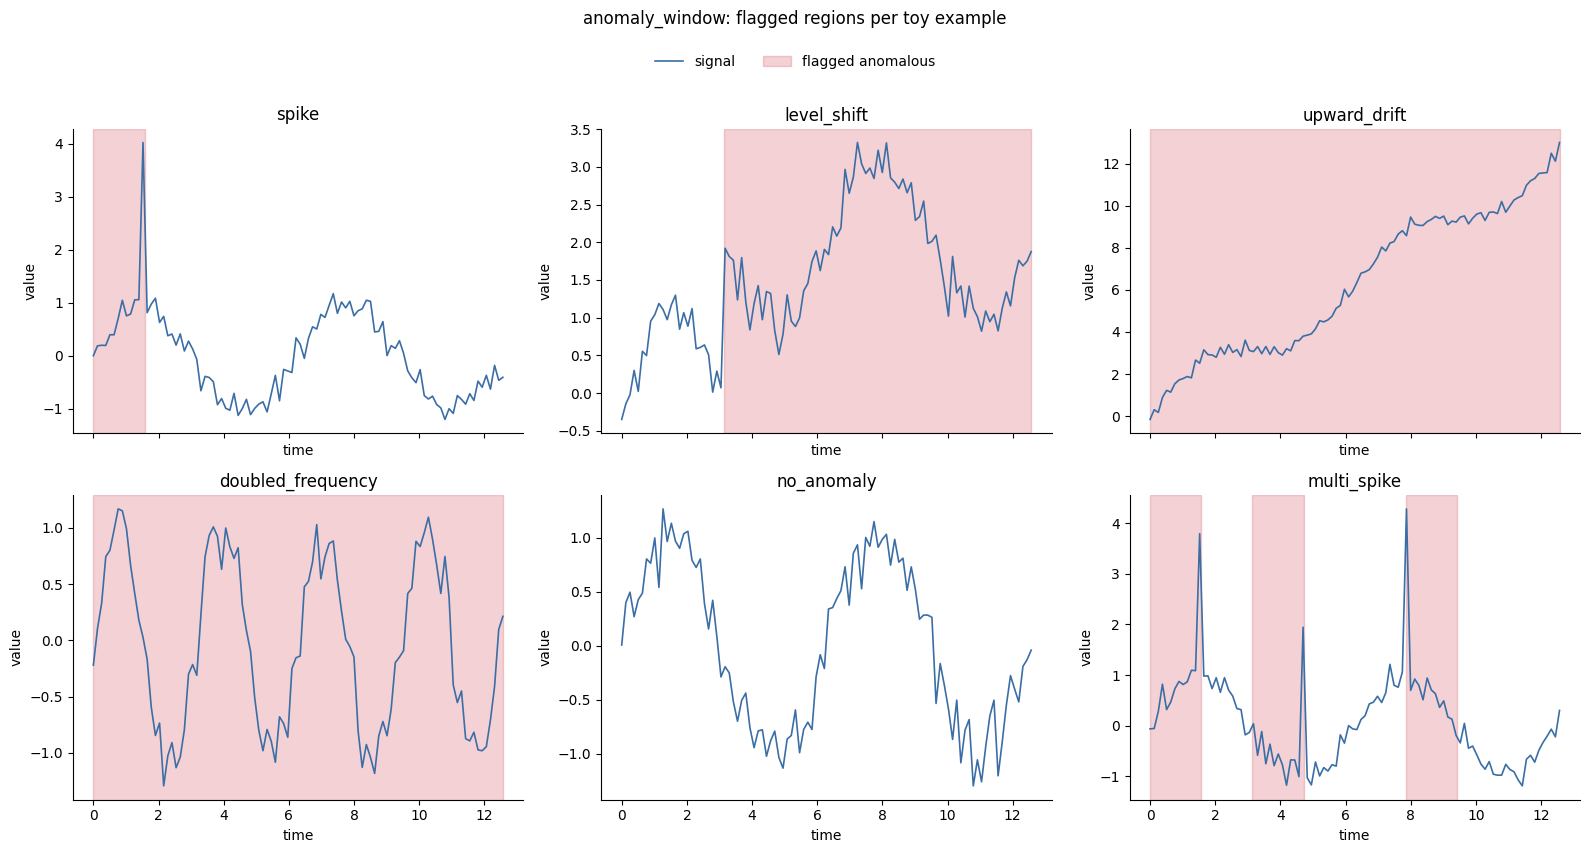

In [7]:
# Visualize the flagged regions against each stream
def merge_intervals(intervals):
    """Merge touching/overlapping (start, end) intervals into contiguous spans, purely
    so adjacent flagged windows render as one solid shaded region instead of a visible
    seam where two separate translucent spans abut."""
    if not intervals:
        return []
    ordered = sorted(intervals)  # merging is only correct on sorted input
    merged = [list(ordered[0])]
    for start, end in ordered[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return [tuple(pair) for pair in merged]


fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.ravel()

line_color = '#3b6ea5'
flag_color = '#d1495b'

for ax, anomaly_type in zip(axes, anomaly_order):
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    time = stream_df['time'].to_numpy()
    output = stream_df['output'].to_numpy()
    intervals = merge_intervals(window_results[anomaly_type])

    ax.plot(time, output, color=line_color, linewidth=1.2, label='signal')
    for j, (start, end) in enumerate(intervals):
        ax.axvspan(start, end, color=flag_color, alpha=0.25,
                   label='flagged anomalous' if j == 0 else None)

    ax.set_title(anomaly_type)
    ax.set_xlabel('time')
    ax.set_ylabel('value')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('anomaly_window: flagged regions per toy example', y=1.06)
plt.tight_layout()
plt.show()

Two results are worth calling out, not just reading off the plot:

- **`level_shift` is detected.** A raw signature is built from increments alone, so it's exactly translation-invariant: a path and the same path shifted by a constant give identical signatures, which is why a level shift is invisible to an unmodified signature. `anomaly_window` adjoins a base point at the origin ahead of every path — the test window's and every corpus stream's — before signing, anchoring each one's absolute height from that fixed point rather than just its shape. That breaks the translation invariance, and every window from the shift onward is flagged.
- **`upward_drift` and `doubled_frequency` are flagged in their entirety** — all eight windows each — and that is the correct answer, not over-flagging. Both differ from the sine corpus in *every* window: the drift signal grows without bound rather than oscillating in place, and the doubled-frequency signal completes two cycles for every one the corpus completes. Neither has a genuinely "normal" sub-interval to localize down to.

`no_anomaly` draws no flags at all, so the 95th-percentile threshold isn't simply firing on everything.

Section 5: A pysegments-style detector, using the paper's own widest-first search

The installed `pysegments` (0.3, built from the project's current GitHub `master` - the wheel in `SigNova-main` is Linux-only, but building from source works here once `pybind11` is supplied and a CMake policy workaround is passed) turned out to implement a different, since-rewritten algorithm than the SigNova paper's Appendix A describes: reading its C++ source (`ExpandingSearcher::search_interval`) shows it scans at unit resolution first and only ever refines *finer*, never coarser - not the paper's widest-first search at all. This section reimplements the paper's own algorithm directly instead, matching its four-step schematic: find the longest clean interval (widest first, narrowing only down to a floor resolution `2**sig_tol` as needed), segment, extend its boundary by steps of `2**tol`, repeat on the complement.

Where this differs from Section 4:

- **Signatures are reconstructed, not recomputed.** Every candidate interval's test-stream and corpus signatures are composed from precomputed dyadic children (`generate_children`, below) via Chen's identity (`iisignature.sigcombine`) rather than rebuilt from raw points. A direct-computation fallback guards intervals that can't be decomposed onto the tree; at `max_depth=20` every unit interval is a leaf, so in practice it never fires (`verbose=True` reports 0 fallbacks throughout).
- **The base point costs one extra `sigcombine` per query.** The jump from the origin depends on where each specific candidate interval starts, so unlike the interval's own signature it can't be baked into the precomputed tree.
- **The covariance matrix is rebuilt fresh per interval**, from the corpus restricted to that same interval, so the whitening basis always matches the scale currently being tested rather than reusing one corpus-wide matrix at a mismatched scale. Section 6 revisits exactly this decision, replacing the per-interval rebuild with a precomputed per-depth one.

Threshold calibration is the same 95th-percentile-of-inliers recipe as Section 4.

In [8]:
#=================================================================================================================================
# Leaf-level signatures only - internal/composed nodes are reconstructed on demand,
# not built eagerly, so no work is spent on nodes that never end up being queried
#=================================================================================================================================

def generate_children(stream, trunc, max_depth):
    """Compute only the leaf-level ("children") signatures of a path, at the finest dyadic
    granularity `max_depth` bisections reach.

    Parameters
    ----------
    stream : array-like, shape (length, width), or (n_streams, length, width) for a batch of
        paths sharing the same index range (e.g. a whole corpus) - iisignature.sig batches
        transparently over any leading shape, so the same recursion handles both.
        No averaging across multiple streams happens anywhere in this construction, so
        Chen's identity composes exactly regardless of node order.
    trunc : int
        Truncation level.
    max_depth : int
        How many times to bisect the stream. Leaf segments are the smallest [lo, hi]
        point ranges produced by recursively splitting at the midpoint down to this
        depth (or until a segment can't be split further, i.e. hi - lo <= 1).

    Returns
    -------
    dict[(int, int), np.ndarray]
        Maps each leaf's raw point-index range `(lo, hi)` - inclusive of both
        endpoints, so consecutive leaves share their boundary point and a later
        `sigcombine` introduces no discontinuity - to its signature(s): shape (D,) for a
        single path, (n_streams, D) for a batch. Computed directly from the raw points.
    """
    stream = np.asarray(stream, dtype=float)
    length = stream.shape[-2]
    children = {}

    def split(lo, hi, depth):
        if depth >= max_depth or hi - lo <= 1:
            children[(lo, hi)] = iisignature.sig(stream[..., lo:hi + 1, :], trunc)
            return
        mid = (lo + hi) // 2
        split(lo, mid, depth + 1)
        split(mid, hi, depth + 1)

    split(0, length - 1, 0)
    return children

In [9]:
#=================================================================================================================================
# On-demand reconstruction from Section 3's dyadic children, plus the base-point augmentation
#=================================================================================================================================

def query_signature(lo, hi, children, cache, width, trunc):
    """Signature(s) of dyadic-aligned range [lo, hi] - a node of the tree `children` was built
    over - composed from `children`/previously-cached subranges via Chen's identity
    (`iisignature.sigcombine`, which batches transparently over any leading shape), memoizing
    every composed node so a repeated or overlapping query reuses it instead of recomposing.

    Only valid for (lo, hi) pairs reachable by the same recursive mid=(lo+hi)//2 bisection
    `generate_children` used - exactly what the widest-first search below queries with -
    raises KeyError otherwise, which callers can catch and fall back to a direct computation.
    """
    if (lo, hi) in children:
        return children[(lo, hi)]
    if (lo, hi) in cache:
        return cache[(lo, hi)]
    if hi <= lo:
        raise KeyError((lo, hi))

    mid = (lo + hi) // 2
    left = query_signature(lo, mid, children, cache, width, trunc)
    right = query_signature(mid, hi, children, cache, width, trunc)
    result = iisignature.sigcombine(left, right, width, trunc)
    cache[(lo, hi)] = result
    return result


def add_base_point(sig, path_at_lo, width, trunc):
    """Chen-combine `sig` (an interval's already-reconstructed signature) with the signature
    of a jump from the origin (0,...,0) to `path_at_lo` (the interval's actual first point),
    anchoring the interval's absolute distance/height from that fixed point rather than just
    its shape - breaks the raw signature's translation invariance, which otherwise makes
    level shifts undetectable (Section 4). `path_at_lo`: shape (width,) for a single path, or
    (n_streams, width) for a batch sharing the leading shape with `sig`. Computed fresh per
    query, since the jump depends on where this specific interval starts - it can't be
    precomputed once as part of the dyadic tree the way the interval's own signature can.
    """
    path_at_lo = np.asarray(path_at_lo, dtype=float)
    origin = np.zeros_like(path_at_lo)
    jump_path = np.stack([origin, path_at_lo], axis=-2)
    jump_sig = iisignature.sig(jump_path, trunc)
    return iisignature.sigcombine(jump_sig, sig, width, trunc)

In [10]:
#=================================================================================================================================
# Widest-first dyadic segmentation, matching SigNova paper Appendix A (Fig. 8) - NOT the
# current pysegments 0.3 library, which implements a different (unit-resolution-first,
# extend-outward) algorithm; this reimplements the paper's own four-step description.
#=================================================================================================================================

def find_longest_clean_dyadic(lo, hi, predicate, min_width):
    """Search [lo, hi] top-down for the widest sub-interval satisfying `predicate`, by
    recursive midpoint bisection, refusing to go narrower than `min_width` (= 2**sig_tol).
    The whole range is tested first; only if that fails is it split into halves, leftmost
    searched before the second.

    The bisection is relative to the `[lo, hi]` it is handed, not to a global dyadic grid
    anchored at 0 - so the complement regions `widest_first_segment` recurses into begin at
    arbitrary offsets, and their midpoints are generally not nodes of the tree
    `generate_children` built. That turns out not to matter at `max_depth=20`: every unit
    interval [i, i+1] is a leaf, so `query_signature`'s recursion always bottoms out on
    leaves that exist, and any (lo, hi) with lo < hi is reconstructible. The caller's
    KeyError fallback is therefore unreachable here - `stats['fallbacks']` reports 0 for
    every toy stream - and only becomes live if the tree is built shallower than unit
    resolution.
    """
    if hi - lo >= min_width and predicate(lo, hi):
        return (lo, hi)
    if hi - lo <= min_width:
        return None

    mid = (lo + hi) // 2
    found = find_longest_clean_dyadic(lo, mid, predicate, min_width)
    if found is not None:
        return found
    return find_longest_clean_dyadic(mid, hi, predicate, min_width)


def initial_extension_step(span, floor):
    """Largest power of two no greater than half the block, but never below `floor`.

    Extension reach scales with what has already been proven clean: a long clean run may
    reach a long way on its first attempt, a short one may not. The floor stops a block at
    the resolution limit from being frozen - half of a 4-point block is 2, below the floor,
    and such a block could otherwise never extend at all.
    """
    half = max(span // 2, 1)
    return max(1 << (half.bit_length() - 1), floor)


def extend_right(lo, hi, region_hi, predicate, floor):
    """Binary-search the furthest right boundary that still passes.

    The step halves on every failure and is never raised again; a success keeps the current
    step and tries the same distance from the new edge. That reaches a distant boundary in
    O(log n) tests where a fixed step needs O(n), and lands on the true boundary rather than
    on the last multiple of some increment.
    """
    step = initial_extension_step(hi - lo, floor)
    while step >= floor:
        candidate = hi + step
        if candidate <= region_hi and predicate(lo, candidate):
            hi = candidate
        else:
            step //= 2
    return hi


def extend_left(lo, hi, region_lo, predicate, floor):
    """Binary-search the furthest left boundary that still passes. See `extend_right`."""
    step = initial_extension_step(hi - lo, floor)
    while step >= floor:
        candidate = lo - step
        if candidate >= region_lo and predicate(candidate, hi):
            lo = candidate
        else:
            step //= 2
    return lo


def widest_first_segment(base_lo, base_hi, predicate, sig_tol, tol):
    """Top-down widest-first segmentation: repeatedly finds the widest clean interval
    anywhere in the current search region (down to resolution 2**sig_tol), extends its
    boundaries outward by binary search as far as they will still pass, records it, and
    recurses on the untouched region(s) before and after it.

    `tol` is the finest extension step rather than the only one. Pass 0 to let the floor
    default to the search's own resolution limit, 2**sig_tol."""
    min_width = 2 ** sig_tol
    floor = 2 ** tol if tol else min_width

    found = []
    stack = [(base_lo, base_hi)]

    while stack:
        lo, hi = stack.pop()
        if hi <= lo:
            continue

        block = find_longest_clean_dyadic(lo, hi, predicate, min_width)
        if block is None:
            continue  # nothing clean anywhere in this piece

        block_lo, block_hi = block
        block_lo = extend_left(block_lo, block_hi, lo, predicate, floor)
        block_hi = extend_right(block_lo, block_hi, hi, predicate, floor)

        found.append((block_lo, block_hi))

        if block_lo > lo:
            stack.append((lo, block_lo))
        if block_hi < hi:
            stack.append((block_hi, hi))

    return found

In [11]:
#=================================================================================================================================
# The detector itself
#=================================================================================================================================

def pysegments_anomaly_detector(stream, stream_time, base_corpus, base_corpus_time,
                                 trunc=2, max_depth=20, tol=0, sig_tol=2,
                                 test_size=0.05, threshold_percentile=95,
                                 random_state=None, verbose=False):
    """Localize anomalies in `stream` using the SigNova paper's own widest-first dyadic
    search (Appendix A) as the interval selection logic, except every candidate interval's
    test-stream and corpus signatures are reconstructed from precomputed dyadic leaf pieces
    via Chen's identity (`iisignature.sigcombine`) instead of recomputed from raw points, a
    base point at the origin is adjoined to keep level shifts detectable, and the covariance
    matrix is rebuilt fresh per interval from the corpus restricted to that same interval (so
    the whitening basis always matches the interval currently being tested, rather than
    reusing one corpus-wide covariance at a mismatched scale).

    `max_depth` bounds the dyadic search resolution: leaves are generated down to max_depth
    bisections, and `sig_tol` should be chosen so the search never needs an interval finer
    than that leaf granularity - any interval that still fails to decompose onto the
    precomputed dyadic tree (e.g. during boundary extension, which steps by a fixed absolute
    width rather than following the tree's own bisection) falls back to a direct computation
    from the raw points, for robustness.

    Per candidate interval, the characteristic function reconstructs the interval's
    base-pointed corpus signatures, builds a covariance matrix from them, splits them 95/5
    (`test_size`) into a training set and held-out inliers, and thresholds at the
    `threshold_percentile`-th percentile of inliers' Mahalanobis nearest-neighbour distance
    to training (95th by default, matching SigNova's own distfit/percentile calibration).

    Returns
    -------
    list of (float, float)
        (start_time, end_time) of every region flagged anomalous - the complement of the
        clean intervals found, matching SigNova._flag's inversion convention.
    """
    stream_values = np.asarray(stream, dtype=float)
    if stream_values.ndim == 1:
        stream_values = stream_values[:, None]
    stream_time = np.asarray(stream_time, dtype=float)
    stream_path = np.column_stack((stream_time, stream_values))

    base_corpus = np.asarray(base_corpus, dtype=float)
    if base_corpus.ndim == 2:
        base_corpus = base_corpus[:, :, None]
    base_corpus_time = np.asarray(base_corpus_time, dtype=float)

    # Resample the corpus onto stream_time's own grid, so corpus_children and
    # stream_children share one index space and every (lo, hi) key means the same thing in
    # both trees - avoids needing two independently-indexed dyadic trees to line up by time.
    n_corpus_total = base_corpus.shape[0]
    base_corpus_resampled = np.stack([
        np.stack([np.interp(stream_time, base_corpus_time, base_corpus[i, :, c])
                  for c in range(base_corpus.shape[2])], axis=-1)
        for i in range(n_corpus_total)
    ])
    corpus_time_channel = np.broadcast_to(stream_time[None, :, None], (n_corpus_total, len(stream_time), 1))
    corpus_path = np.concatenate([corpus_time_channel, base_corpus_resampled], axis=2)

    width = stream_path.shape[1]
    T = len(stream_path) - 1

    stream_children = generate_children(stream_path, trunc, max_depth)
    corpus_children = generate_children(corpus_path, trunc, max_depth)
    stream_cache, corpus_cache = {}, {}
    rng = np.random.default_rng(random_state)

    stats = {'calls': 0, 'fallbacks': 0}

    def raw_signature(path, lo, hi):
        return iisignature.sig(path[..., lo:hi + 1, :], trunc)

    def AD(lo, hi):
        lo, hi = max(0, lo), min(T, hi)
        stats['calls'] += 1
        try:
            test_sig = query_signature(lo, hi, stream_children, stream_cache, width, trunc)
            corpus_sigs = query_signature(lo, hi, corpus_children, corpus_cache, width, trunc)
        except KeyError:
            stats['fallbacks'] += 1
            test_sig = raw_signature(stream_path, lo, hi)
            corpus_sigs = raw_signature(corpus_path, lo, hi)

        test_sig = add_base_point(test_sig, stream_path[lo], width, trunc)
        corpus_sigs = add_base_point(corpus_sigs, corpus_path[:, lo, :], width, trunc)

        L_inv = build_covariance_matrix(corpus_sigs)

        n_corpus = corpus_sigs.shape[0]
        n_inliers = max(1, round(test_size * n_corpus))
        inlier_idx = rng.choice(n_corpus, size=n_inliers, replace=False)
        inlier_mask = np.zeros(n_corpus, dtype=bool)
        inlier_mask[inlier_idx] = True

        train_sigs = corpus_sigs[~inlier_mask]
        inlier_sigs = corpus_sigs[inlier_mask]

        inlier_distances = mKNN(inlier_sigs, L_inv, train_sigs, k=1)
        threshold = np.percentile(inlier_distances, threshold_percentile)
        test_distance = mKNN(test_sig[None, :], L_inv, train_sigs, k=1)[0]

        return bool(test_distance <= threshold)

    clean_intervals = widest_first_segment(0, T, AD, sig_tol, tol)

    if verbose:
        print('AD calls:', stats['calls'], '- raw-computation fallbacks:', stats['fallbacks'])

    clean_sorted = sorted(clean_intervals)
    anomalous_ranges = []
    cursor = 0
    for c_lo, c_hi in clean_sorted:
        if c_lo > cursor:
            anomalous_ranges.append((cursor, c_lo))
        cursor = max(cursor, c_hi)
    if cursor < T:
        anomalous_ranges.append((cursor, T))

    return [(float(stream_time[lo]), float(stream_time[hi])) for lo, hi in anomalous_ranges]

In [12]:
# Run pysegments_anomaly_detector on every toy example, against the Section 1 sine corpus.
#
# Unlike anomaly_window, generate_children/query_signature cache every dyadic node's
# signature simultaneously for the whole corpus batch the tree is built over. That is fine
# at anomaly_window's per-window scale, but holding ~200 arrays of shape (n_corpus, D) at
# once exhausts memory at the full 10,000 streams, on top of everything already resident
# from Sections 1-4 (confirmed: MemoryError). A random subsample is a representative
# reference corpus at a fraction of the footprint.
pysegments_rng = np.random.default_rng(0)
pysegments_corpus_idx = pysegments_rng.choice(corpus.shape[0], size=5000, replace=False)
pysegments_corpus = corpus[pysegments_corpus_idx]

pysegments_results = {}

for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    stream_time = stream_df['time'].to_numpy()
    stream_values = stream_df['output'].to_numpy()

    intervals = pysegments_anomaly_detector(
        stream_values, stream_time, pysegments_corpus, t_corpus,
        trunc=TRUNC, max_depth=20, tol=0, sig_tol=2, test_size=0.05,
        threshold_percentile=95, random_state=0, verbose=True,
    )
    pysegments_results[anomaly_type] = intervals
    print(anomaly_type, '->', intervals)

AD calls: 26 - raw-computation fallbacks: 0
spike -> [(1.3962634015954636, 1.6501294746128208)]


AD calls: 35 - raw-computation fallbacks: 0
level_shift -> [(3.0463928762082846, 12.566370614359172)]


AD calls: 34 - raw-computation fallbacks: 0
upward_drift -> [(0.0, 12.566370614359172)]


AD calls: 71 - raw-computation fallbacks: 0
doubled_frequency -> [(0.0, 5.07732146034714), (7.489049154012032, 11.297040249272388)]


AD calls: 1 - raw-computation fallbacks: 0
no_anomaly -> []


AD calls: 95 - raw-computation fallbacks: 0
multi_spike -> [(1.3962634015954636, 1.6501294746128208), (4.569589314312426, 4.823455387329783), (7.742915227029389, 7.996781300046746)]


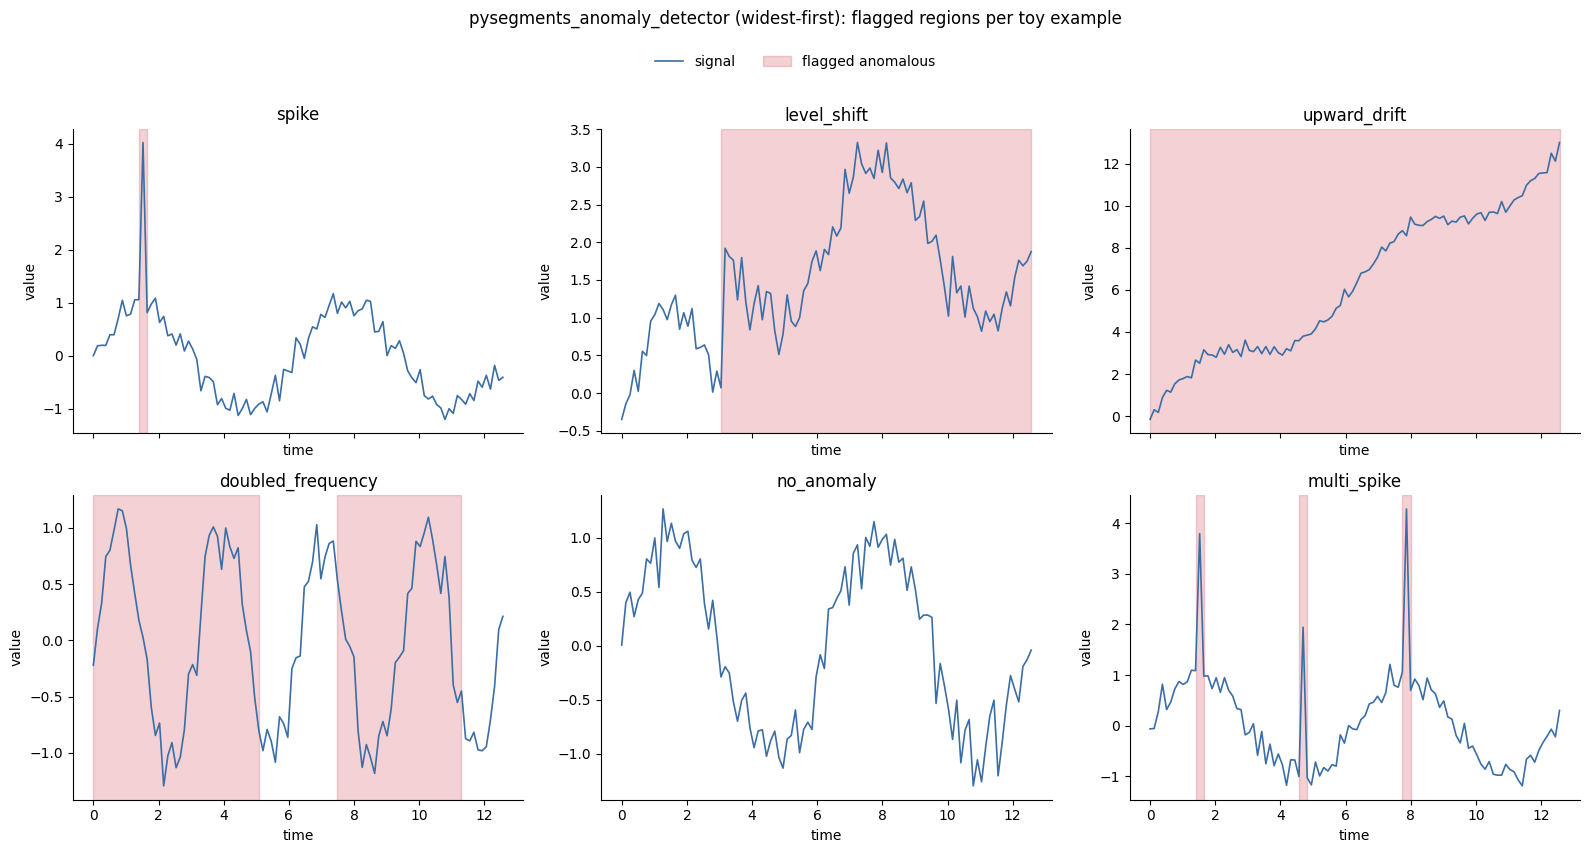

In [13]:
# Visualize the flagged regions against each stream, same layout/convention as Section 4
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for ax, anomaly_type in zip(axes, anomaly_order):
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    time = stream_df['time'].to_numpy()
    output = stream_df['output'].to_numpy()
    intervals = merge_intervals(pysegments_results[anomaly_type])

    ax.plot(time, output, color=line_color, linewidth=1.2, label='signal')
    for j, (start, end) in enumerate(intervals):
        ax.axvspan(start, end, color=flag_color, alpha=0.25,
                   label='flagged anomalous' if j == 0 else None)

    ax.set_title(anomaly_type)
    ax.set_xlabel('time')
    ax.set_ylabel('value')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('pysegments_anomaly_detector (widest-first): flagged regions per toy example', y=1.06)
plt.tight_layout()
plt.show()

Comparing honestly against `anomaly_window` (Section 4):

- **Every one of the five real anomalies is caught, and `no_anomaly` draws nothing.** No false positive, no miss.
- **`spike` and `multi_spike` are localized far more tightly than Section 4 manages.** The spikes sit at `t = pi/2`, `3pi/2`, `5pi/2` (1.571, 4.712, 7.854); the flagged intervals are (1.40, 1.65), (4.57, 4.82) and (7.74, 8.00), each a ~0.25-wide bracket around its spike. Section 4 can only ever answer at the resolution of its fixed windows, so the same spikes come back as whole `2*pi/8`-wide blocks. This is the widest-first search doing exactly what it is for: staying coarse over clean stretches and refining only where a test fails.
- **`level_shift` and `upward_drift` behave as in Section 4** - flagged from the shift onward, and over the entire range, respectively.
- **`doubled_frequency` is the one place Section 4 is more complete.** Section 5 flags (0, 5.08) and (7.49, 11.30), leaving two gaps that Section 4's fixed windows all reject. A doubled-frequency sine still passes through configurations that locally resemble the corpus, and widest-first accepts the first sub-interval that passes rather than insisting every window agree.

The cost side is visible in the `AD calls` counters: `no_anomaly` terminates after a **single** call, because the whole range passes on the first test and the search stops immediately. `spike` and `multi_spike` need 26 and 95 calls to isolate their narrow intervals. That is the intended trade - cheap on clean data, more expensive exactly where there is something to find.

Section 6: Part two of Section 3 — one pooled corpus of every dyadic interval

This is the continuation promised in Section 3, placed after Section 5 because it reuses that section's `widest_first_segment` search and its `query_signature` / `add_base_point` helpers.

Section 3 built a dyadic tree to make *one stream's* interval signatures cheap to look up. Section 5 then used it, but still did all the *corpus* work per candidate: for every interval the search tested, it sliced the corpus to that interval, signed all 5,000 streams, built a covariance matrix, split train/inliers and calibrated a threshold — then threw all of it away and did it again for the next candidate.

Section 6 inverts that. The dyadic tree is built over the corpus **once**, every node of it, giving one large pooled corpus of interval signatures; the Mahalanobis distance is fitted from that pool's covariance; and the same widest-first search then runs with a characteristic function that is a single lookup. The corpus work moves from once-per-candidate to once, full stop.

The open question is what "that pool's covariance" should mean, because the pool mixes **scales**. A signature term at level *k* grows like (duration)^*k*, so the full-range intervals and the 2-point leaves sit many orders of magnitude apart in the same coordinates. Two answers are worth measuring rather than assuming, so this section is split:

- **Section 6a** fits **one** `Sigma^-1/2` across the entire pool and uses it for every query, whatever the candidate's width. Simplest, and cheapest at query time: one whitening matrix, and a single FAISS index shared by every depth.
- **Section 6b** fits a **separate** `Sigma^-1/2` per tree depth, each from only that depth's intervals. Keeps the whitening basis matched to the scale being tested — the property Section 5 was paying for by rebuilding per interval — but costs one index per visited depth, since each depth is whitened differently.

Both share one pooled corpus, built once and passed to 6b via `share_from`, so they are compared on byte-identical data and differ in the whitening and nothing else. Thresholds stay per-depth in both, which keeps the whitening as the single variable — and is also what gives 6a a fair test, since under one global whitening the distance scale still varies with interval width, so a single global threshold would pass every narrow interval and fail every wide one regardless of whether anything was anomalous.

Nearest-neighbour search deliberately goes against the **whole** pooled set in both variants rather than only same-width intervals. Whether that mixes scales in practice is measured, not assumed — the detector reports what fraction of nearest neighbours came from the query's own depth.

One concession to hardware throughout: a FAISS index over the full 1.97M-vector pool needs ~490 MB, and 6b needs one per depth — several GB, which does not fit in this machine's 7.8 GB alongside everything else. The **covariance** is fitted on the full pool in both variants; only the **searchable** set is subsampled, stratified across depths, via `nn_reference_size`. For 6a's global fit even the covariance would need a ~980 MB float64 copy, so `build_whitening_from_blocks` folds the pool in chunk by chunk instead — exact, not approximate.

In [14]:
#=================================================================================================================================
# Every dyadic interval's signature, for every corpus stream, in one pass
#=================================================================================================================================

def build_pooled_dyadic_corpus(corpus_path, trunc, max_depth, dtype=np.float32):
    """Signatures of *every* node of the dyadic tree - not just the leaves - for a whole
    batch of paths at once, grouped by depth.

    Section 5's `generate_children` deliberately computes leaves only, leaving internal
    nodes to be reconstructed on demand so nothing is spent on nodes never queried. Here the
    opposite is wanted: the whole tree is the corpus, so every node is built. Chen's identity
    still does the work - only the leaves call `iisignature.sig`, and each internal node is
    one `sigcombine` of its two children - so building all ~200 nodes costs about one extra
    combine per node rather than a fresh signature computation each.

    Each node's signature is base-pointed (`add_base_point`) before being stored, matching
    what the detector will compute for a candidate interval, so level shifts stay visible.

    Memory: the recursion returns float64 upward so composition keeps full precision, but
    only stores the float32 base-pointed result. Because a child's float64 array becomes
    garbage as soon as its parent has consumed it, peak float64 residency is O(tree depth)
    rather than O(number of nodes) - which is what makes the full 10,000-stream corpus fit.

    Parameters
    ----------
    corpus_path : array-like, shape (n_streams, length, width)
        Batch of paths sharing one index range, time channel included.
    trunc : int
        Signature truncation level.
    max_depth : int
        Bisection depth limit; at 20 the tree bottoms out at unit intervals.
    dtype : numpy dtype
        Storage dtype for the pooled signatures. float32 halves the footprint and is well
        within FAISS's own precision.

    Returns
    -------
    (pooled, intervals)
        `pooled[depth]` is an (n_nodes_at_depth * n_streams, D) array; `intervals[depth]`
        is the matching list of (lo, hi) point ranges, in the same block order.
    """
    corpus_path = np.asarray(corpus_path, dtype=float)
    length, width = corpus_path.shape[-2], corpus_path.shape[-1]

    pooled, intervals = {}, {}

    def split(lo, hi, depth):
        if depth >= max_depth or hi - lo <= 1:
            sig = iisignature.sig(corpus_path[..., lo:hi + 1, :], trunc)
        else:
            mid = (lo + hi) // 2
            left = split(lo, mid, depth + 1)
            right = split(mid, hi, depth + 1)
            sig = iisignature.sigcombine(left, right, width, trunc)

        base_pointed = add_base_point(sig, corpus_path[..., lo, :], width, trunc)
        pooled.setdefault(depth, []).append(np.asarray(base_pointed, dtype=dtype))
        intervals.setdefault(depth, []).append((lo, hi))
        return sig

    split(0, length - 1, 0)

    pooled = {d: np.concatenate(blocks, axis=0) for d, blocks in pooled.items()}
    return pooled, intervals

In [15]:
#=================================================================================================================================
# Fitting one whitening jointly across the whole pool, in bounded memory
#=================================================================================================================================

def build_whitening_from_blocks(blocks, rcond=1e-12, chunk_rows=200_000):
    """Sigma^-1/2 fitted across several arrays at once, without ever materialising them as a
    single float64 matrix.

    Section 6a needs one whitening fitted over the entire pooled corpus - all depths stacked
    together, ~1.97M x 62. Concatenating and casting that to float64 would cost ~980 MB,
    which does not fit here alongside the pool itself. Instead this makes two streaming
    passes: one to accumulate the global mean, one to fold each centred chunk into a running
    QR factor.

    Stacking `[R_prev; chunk]` and re-factorising is exact, not an approximation: R is always
    (D, D) and carries the same singular values and right singular vectors as the full
    stacked matrix, so the result matches `build_covariance_matrix` applied to the
    concatenation to machine precision (verified to ~5e-16, independent of `chunk_rows`),
    at O(chunk_rows x D) memory instead of O(total_rows x D).

    As in `build_covariance_matrix`, this deliberately avoids forming X^T X, which would
    square an already-brutal condition number - and the condition number here is worse than
    anywhere else in the notebook, since the pool mixes interval widths spanning two orders
    of magnitude and therefore signature terms spanning many more.
    """
    D = blocks[0].shape[1]
    total = sum(b.shape[0] for b in blocks)

    accumulator = np.zeros(D, dtype=np.float64)
    for block in blocks:
        accumulator += block.sum(axis=0, dtype=np.float64)
    mu = accumulator / total

    R = np.zeros((0, D), dtype=np.float64)
    for block in blocks:
        for start in range(0, block.shape[0], chunk_rows):
            chunk = np.asarray(block[start:start + chunk_rows], dtype=np.float64) - mu
            R = np.linalg.qr(np.vstack([R, chunk]), mode='r')

    _, s, Vt = np.linalg.svd(R, full_matrices=False)

    scale = np.zeros_like(s)
    if s.size and s.max() > 0:
        keep = s > rcond * s.max()
        scale[keep] = np.sqrt(total) / s[keep]

    return (Vt.T * scale) @ Vt


def report_whitening(reference, label):
    """Print how many whitening matrices and FAISS indices a reference actually built, and
    how many directions each whitening retains.

    The retained rank is the diagnostic that matters for comparing 6a against 6b: `rcond`
    drops any direction whose singular value is negligible next to the largest, so a
    whitening fitted across wildly mismatched scales will silently discard the directions
    that describe the narrow intervals.
    """
    built = sorted(reference._L_inv, key=str)
    print('{0}: {1} whitening matrix/matrices, {2} FAISS index/indices built'.format(
        label, len(built), reference._index_builds))

    if reference.whitening == 'per_interval':
        # One line per node would be ~40 lines of noise; the spread is the informative part.
        ranks = [int(np.linalg.matrix_rank(reference._L_inv[k])) for k in built]
        print('    {0} dyadic node(s) visited, rank {1} to {2} of {3}'.format(
            len(built), min(ranks), max(ranks), reference.reference.shape[1]))
        print('    at most {0} index/indices resident at once, {1} built in total'.format(
            reference.index_cache_size, reference._index_builds))
        return

    for key in built:
        rank = int(np.linalg.matrix_rank(reference._L_inv[key]))
        where = ('all depths pooled' if key == 'global'
                 else 'depth {0} (median width {1:.0f})'.format(key, reference.depth_widths[key]))
        print('    {0:<34} rank {1:>3} of {2}'.format(where, rank, reference.reference.shape[1]))

In [16]:
#=================================================================================================================================
# The pooled reference: one searchable set, whitened either globally (6a) or per depth (6b)
#=================================================================================================================================

class PooledDyadicReference:
    """A reference model built once from every dyadic interval of every corpus stream.

    Replaces the per-candidate corpus work `pysegments_anomaly_detector` does (slice, sign,
    build covariance, split, calibrate - for every interval the search tests) with a single
    up-front build. Scoring an interval afterwards is one whitening and one FAISS query.

    `whitening` selects the one variable Sections 6a and 6b differ on:

    - `'global'` (6a): a single Sigma^-1/2 fitted across the *entire* pool, every depth
      stacked together, then used for every query whatever the candidate's width. One
      whitening matrix, and one FAISS index shared by every depth.
    - `'per_depth'` (6b): a separate Sigma^-1/2 per depth, each fitted only on that depth's
      own intervals. Costs one index per visited depth, since each is whitened differently.
    - `'per_interval'` (6c): a separate Sigma^-1/2 per *dyadic node*, fitted only on the
      corpus intervals occupying that exact node - one per corpus stream. Finer than
      per-depth, which still pools every position at a given scale together. The searchable
      reference is unchanged: still the whole pool, exactly as in 6a and 6b. Only the
      coordinates it is measured in change, and they now change per node rather than per
      depth, so an index cannot be shared between nodes - see `index_cache_size`.

    Thresholds stay per-depth in *both* modes. That is deliberate. It keeps the whitening as
    the single variable under test, and it is also what gives 6a a fair hearing: under one
    global whitening the distance scale still varies enormously with interval width, so a
    single global threshold would just pass every narrow interval and fail every wide one
    (or the reverse), telling us nothing about the whitening itself.

    **Every whitening uses all pooled intervals from all corpus streams.** Affordable because
    neither fit materialises the pool as one float64 matrix: `build_covariance_matrix` takes
    a QR before the SVD, and the global fit uses `build_whitening_from_blocks`, which folds
    the pool in chunk by chunk.

    **The kNN reference set is subsampled; the covariance is not.** A FAISS index over the
    whole pool would need ~490 MB, and in `'per_depth'` mode each depth needs its own -
    several GB in total, which does not fit here. `nn_reference_size` caps the searchable set
    (stratified proportionally across depths, so no depth drops out). Threshold-calibration
    inliers are drawn from rows *excluded* from that subsample, so an inlier can never match
    itself at distance zero.

    Whitening matrices, FAISS indices and thresholds are all built lazily, so depths the
    search never visits - anything narrower than `2**sig_tol` - cost nothing.

    Pass `share_from=<another reference>` to reuse an already-built pool and reference
    subsample and change only the whitening. Building the pool is by far the expensive part,
    so 6b shares 6a's rather than paying for it a second time - which also guarantees the two
    sections are compared on byte-identical data.
    """

    def __init__(self, base_corpus=None, base_corpus_time=None, trunc=None, max_depth=20,
                 nn_reference_size=250_000, test_size=0.05, threshold_percentile=95,
                 random_state=None, whitening='per_depth', share_from=None,
                 index_cache_size=16):
        if whitening not in ('global', 'per_depth', 'per_interval'):
            raise ValueError("whitening must be 'global', 'per_depth' or 'per_interval', "
                             'got {0!r}'.format(whitening))
        self.whitening = whitening
        self.threshold_percentile = threshold_percentile
        self.test_size = test_size
        self.index_cache_size = index_cache_size

        if share_from is not None:
            # Reuse the pool wholesale; only the whitening differs between 6a and 6b.
            self.pooled = share_from.pooled
            self.intervals = share_from.intervals
            self.depth_widths = share_from.depth_widths
            self.reference = share_from.reference
            self.reference_depth = share_from.reference_depth
            self._inliers = share_from._inliers
            self._reference_mask = share_from._reference_mask
            self.trunc = share_from.trunc
            self.width = share_from.width
            self.n_corpus = share_from.n_corpus
        else:
            base_corpus = np.asarray(base_corpus, dtype=float)
            if base_corpus.ndim == 2:
                base_corpus = base_corpus[:, :, None]
            base_corpus_time = np.asarray(base_corpus_time, dtype=float)

            self.n_corpus, length = base_corpus.shape[0], base_corpus.shape[1]
            time_channel = np.broadcast_to(base_corpus_time[None, :, None],
                                           (self.n_corpus, length, 1))
            corpus_path = np.concatenate([time_channel, base_corpus], axis=2)

            self.trunc = trunc
            self.width = corpus_path.shape[2]

            self.pooled, self.intervals = build_pooled_dyadic_corpus(corpus_path, trunc, max_depth)
            self.depth_widths = {d: float(np.median([hi - lo for lo, hi in v]))
                                 for d, v in self.intervals.items()}

            # Stratified split of each depth into (searchable reference | calibration inliers).
            rng = np.random.default_rng(random_state)
            pool_total = sum(v.shape[0] for v in self.pooled.values())
            keep_fraction = min(1.0, nn_reference_size / pool_total)

            reference_blocks, reference_depths = [], []
            self._inliers, self._reference_mask = {}, {}

            for d in sorted(self.pooled):
                n_d = self.pooled[d].shape[0]
                n_reference = max(1, int(round(keep_fraction * n_d)))
                permutation = rng.permutation(n_d)
                reference_idx, remainder_idx = permutation[:n_reference], permutation[n_reference:]

                reference_blocks.append(self.pooled[d][reference_idx])
                reference_depths.append(np.full(n_reference, d, dtype=np.int16))

                # Which pooled rows ended up searchable, so 'per_interval' can draw a node's
                # calibration inliers from the rows that did not.
                mask = np.zeros(n_d, dtype=bool)
                mask[reference_idx] = True
                self._reference_mask[d] = mask

                n_inliers = max(1, int(round(test_size * n_d)))
                held_out = remainder_idx if remainder_idx.size else reference_idx
                self._inliers[d] = self.pooled[d][held_out[:n_inliers]]

            self.reference = np.concatenate(reference_blocks, axis=0)
            self.reference_depth = np.concatenate(reference_depths)

        self._L_inv, self._index, self._thresholds = {}, {}, {}
        self._node_bounds = {}
        self._index_builds = 0

    def _key(self, depth, node=None):
        """One shared slot in 'global' mode, one per depth in 'per_depth', one per dyadic
        node in 'per_interval'."""
        if self.whitening == 'global':
            return 'global'
        if self.whitening == 'per_depth':
            return depth
        return (depth, node)

    def _threshold_key(self, depth, node=None):
        """Thresholds stay per-depth in 'global' and 'per_depth' mode - see the class
        docstring - and go per-node in 'per_interval', since the metric does."""
        return (depth, node) if self.whitening == 'per_interval' else depth

    # ---- addressing one node of the pool ------------------------------------------------
    def node_pool(self, depth, node):
        """The corpus intervals occupying one dyadic node - one per corpus stream, nothing else.

        `build_pooled_dyadic_corpus` concatenates each depth's nodes in the order
        `intervals[depth]` records them, `n_corpus` rows per node, which is what makes this a
        slice rather than a search.
        """
        start = node * self.n_corpus
        return self.pooled[depth][start:start + self.n_corpus]

    def node_for_index(self, depth, lo, hi):
        """Index of the node at `depth` that best matches an arbitrary query interval.

        The search tests intervals that are not tree nodes at all - boundary extension steps
        by a fixed absolute width - so 'which node is this?' has to be answered by position
        rather than by tree address. Widest overlap wins; a query overlapping nothing falls
        back to the nearest centre.
        """
        if depth not in self._node_bounds:
            spans = np.asarray(self.intervals[depth], dtype=float)
            self._node_bounds[depth] = (spans[:, 0], spans[:, 1])
        starts, ends = self._node_bounds[depth]
        overlap = np.minimum(hi, ends) - np.maximum(lo, starts)
        centre_gap = np.abs((starts + ends) - (lo + hi))
        return int(np.lexsort((centre_gap, -overlap))[0])

    # ---- lazily built ------------------------------------------------------------------
    def L_inv(self, depth, node=None):
        """Sigma^-1/2 - fitted across the whole pool in 'global' mode, on `depth`'s own
        intervals in 'per_depth', or on one node's intervals in 'per_interval'. Every corpus
        stream contributes in all three; what changes is how many *positions and widths* are
        averaged together to get there."""
        key = self._key(depth, node)
        if key not in self._L_inv:
            if self.whitening == 'global':
                self._L_inv[key] = build_whitening_from_blocks(
                    [self.pooled[d] for d in sorted(self.pooled)])
            elif self.whitening == 'per_depth':
                self._L_inv[key] = build_covariance_matrix(self.pooled[depth])
            else:
                self._L_inv[key] = build_covariance_matrix(self.node_pool(depth, node))
        return self._L_inv[key]

    def index(self, depth, node=None):
        """FAISS index over the whole reference subsample, whitened by the matrix that applies
        to `depth`.

        Every depth's intervals are searchable from every query, per the design choice to pool
        rather than restrict to same-width neighbours - but they are compared in whichever
        whitened coordinates apply, which is the only way a single distance is well-defined.
        In 'global' mode there is only ever one index, which is a real cost advantage over
        'per_depth': no rebuild as the search moves between scales.
        """
        key = self._key(depth, node)
        if key in self._index:
            self._index[key] = self._index.pop(key)      # least-recently-used ordering
            return self._index[key]

        X = transform_signatures(self.reference, self.L_inv(depth, node)).astype('float32')
        index = faiss.IndexFlatL2(X.shape[1])
        index.add(X)
        self._index[key] = index
        self._index_builds += 1

        # 'per_interval' can visit dozens of nodes, and each index is the whole reference
        # subsample re-whitened, so they cannot all stay resident. 'global' and 'per_depth'
        # build a handful and keep them.
        if self.whitening == 'per_interval':
            while len(self._index) > self.index_cache_size:
                self._index.pop(next(iter(self._index)))
        return self._index[key]

    def threshold(self, depth, node=None):
        """`threshold_percentile`-th percentile of held-out inliers' nearest-neighbour distance
        - the same calibration recipe as Sections 4 and 5, run once per depth (or per node in
        'per_interval' mode) instead of once per candidate interval.

        It has to follow the whitening: distances measured in different whitened coordinates
        are not comparable, so a per-node metric needs a per-node threshold or the comparison
        is meaningless.
        """
        key = self._threshold_key(depth, node)
        if key not in self._thresholds:
            inliers = (self._node_inliers(depth, node) if self.whitening == 'per_interval'
                       else self._inliers[depth])
            queries = transform_signatures(inliers, self.L_inv(depth, node)).astype('float32')
            distances, _ = self.index(depth, node).search(queries, 1)
            self._thresholds[key] = float(
                np.percentile(distances[:, 0], self.threshold_percentile))
        return self._thresholds[key]

    def _node_inliers(self, depth, node):
        """Calibration inliers for one node: its own corpus intervals, minus any that went
        into the searchable reference, so an inlier can never match itself at distance zero."""
        start = node * self.n_corpus
        in_reference = self._reference_mask[depth][start:start + self.n_corpus]
        available = np.flatnonzero(~in_reference)
        if available.size == 0:
            available = np.arange(self.n_corpus)
        n_inliers = max(1, int(round(self.test_size * self.n_corpus)))
        return self.node_pool(depth, node)[available[:n_inliers]]

    # ---- querying ---------------------------------------------------------------------
    def depth_for_width(self, width):
        """Map an arbitrary interval width onto the pooled depth whose intervals are closest in
        width, compared on a log scale since widths halve from one depth to the next.

        Needed because the search tests intervals that are not tree nodes at all - boundary
        extension steps by a fixed absolute width - so 'which depth is this?' has to be
        answered by scale rather than by tree position. Still needed in 'global' mode, where it
        selects the threshold even though the whitening no longer varies.
        """
        width = max(int(width), 1)
        return min(self.depth_widths,
                   key=lambda d: abs(np.log2(self.depth_widths[d]) - np.log2(width)))

    def score(self, signature, depth, node=None):
        """Squared Mahalanobis distance from `signature` to its nearest pooled neighbour, in
        whichever whitened space applies. Returns (distance, depth the neighbour came from)."""
        query = transform_signatures(signature, self.L_inv(depth, node)).astype('float32')
        distances, neighbours = self.index(depth, node).search(query, 1)
        return float(distances[0, 0]), int(self.reference_depth[neighbours[0, 0]])

In [17]:
#=================================================================================================================================
# The detector: identical widest-first search to Section 5, but every characteristic-function
# call is a lookup against the prebuilt pooled reference instead of a fresh corpus rebuild
#=================================================================================================================================

def pooled_anomaly_detector(stream, stream_time, reference,
                             max_depth=20, tol=0, sig_tol=2, verbose=False):
    """Localize anomalies in `stream` using the same `widest_first_segment` search as
    Section 5, scored against a prebuilt `PooledDyadicReference`.

    The only thing that changes relative to `pysegments_anomaly_detector` is what happens
    inside the characteristic function. Section 5, per candidate interval: slice the corpus,
    sign it, build a covariance matrix, split train/inliers, calibrate a threshold, search.
    Here: reconstruct the interval's own signature (still via Chen's identity from the
    stream's dyadic tree), pick the pooled depth matching its width, and do one FAISS query
    against that depth's already-whitened, already-calibrated reference. No corpus work at
    all happens per candidate.

    `verbose` reports the number of characteristic-function calls, and what fraction of
    nearest neighbours were drawn from the query's own depth rather than another - a check
    on whether pooling every depth into one searchable reference actually mixes scales in
    practice, or whether same-scale intervals simply win on distance anyway.

    Returns
    -------
    list of (float, float)
        (start_time, end_time) of every region flagged anomalous - the complement of the
        clean intervals found, matching SigNova._flag's inversion convention.
    """
    stream_values = np.asarray(stream, dtype=float)
    if stream_values.ndim == 1:
        stream_values = stream_values[:, None]
    stream_time = np.asarray(stream_time, dtype=float)
    stream_path = np.column_stack((stream_time, stream_values))

    trunc, width = reference.trunc, reference.width
    if stream_path.shape[1] != width:
        raise ValueError('stream width {0} does not match reference width {1}'
                         .format(stream_path.shape[1], width))

    T = len(stream_path) - 1
    stream_children = generate_children(stream_path, trunc, max_depth)
    stream_cache = {}
    stats = {'calls': 0, 'same_depth_nn': 0}

    def AD(lo, hi):
        lo, hi = max(0, lo), min(T, hi)
        stats['calls'] += 1

        sig = query_signature(lo, hi, stream_children, stream_cache, width, trunc)
        sig = add_base_point(sig, stream_path[lo], width, trunc)

        depth = reference.depth_for_width(hi - lo)
        # 'per_interval' references key on the dyadic node, not just its depth; the other two
        # modes ignore `node` entirely, so this changes nothing for 6a or 6b.
        node = (reference.node_for_index(depth, lo, hi)
                if reference.whitening == 'per_interval' else None)
        distance, neighbour_depth = reference.score(sig[None, :], depth, node)
        if neighbour_depth == depth:
            stats['same_depth_nn'] += 1

        return bool(distance <= reference.threshold(depth, node))

    clean_intervals = widest_first_segment(0, T, AD, sig_tol, tol)

    if verbose:
        same = stats['same_depth_nn'] / stats['calls'] * 100 if stats['calls'] else 0.0
        print('AD calls: {0} - nearest neighbour came from the query\'s own depth {1:.0f}% of the time'
              .format(stats['calls'], same))

    clean_sorted = sorted(clean_intervals)
    anomalous_ranges = []
    cursor = 0
    for c_lo, c_hi in clean_sorted:
        if c_lo > cursor:
            anomalous_ranges.append((cursor, c_lo))
        cursor = max(cursor, c_hi)
    if cursor < T:
        anomalous_ranges.append((cursor, T))

    return [(float(stream_time[lo]), float(stream_time[hi])) for lo, hi in anomalous_ranges]

Section 6a: one global covariance, used at every depth

Fit a single `Sigma^-1/2` across the whole pool — all 1.97M interval signatures, every depth stacked together — and whiten every query with it regardless of the candidate's width.

This is the simplest thing that could work, and at query time it is strictly cheaper than 6b: one whitening matrix to fit, and **one** FAISS index that serves every depth, so the search never rebuilds an index as it moves between scales.

The thing to watch is the retained rank. `build_covariance_matrix` and `build_whitening_from_blocks` both drop directions whose singular value is negligible relative to the largest (`rcond=1e-12`), which is necessary — otherwise the whitening divides by numerical noise. But a covariance fitted across intervals whose widths span 99 points down to 1 is dominated by the widest, and the directions that describe the narrow intervals may fall under that threshold and be discarded outright. If that happens, narrow candidates are being whitened by a basis that has thrown away the coordinates describing them.

The run below reports the rank each whitening actually retains, out of 62, so this is visible rather than inferred.

In [18]:
# Section 6a: build the pool once over the FULL 10,000-stream corpus, whitened by ONE
# global covariance. Section 6b reuses this exact pool with a per-depth whitening, so the
# two are compared on byte-identical data.
import time

t0 = time.perf_counter()
reference_6a = PooledDyadicReference(
    corpus, t_corpus, trunc=TRUNC, max_depth=20,
    nn_reference_size=250_000, test_size=0.05, threshold_percentile=95,
    random_state=0, whitening='global',
)
pool_build_seconds = time.perf_counter() - t0

print('pool built in {0:.1f}s from {1:,} corpus streams\n'.format(
    pool_build_seconds, reference_6a.n_corpus))

print('{0:>6}  {1:>7}  {2:>14}  {3:>12}  {4:>10}'.format(
    'depth', 'nodes', 'pooled vectors', 'median width', 'MB'))
for d in sorted(reference_6a.pooled):
    block = reference_6a.pooled[d]
    print('{0:>6}  {1:>7}  {2:>14,}  {3:>12.0f}  {4:>10.1f}'.format(
        d, len(reference_6a.intervals[d]), block.shape[0],
        reference_6a.depth_widths[d], block.nbytes / 1e6))

pool_total = sum(v.shape[0] for v in reference_6a.pooled.values())
pool_mb = sum(v.nbytes for v in reference_6a.pooled.values()) / 1e6
print('\n{0:,} pooled interval signatures in total ({1:.0f} MB float32), dimension {2}'.format(
    pool_total, pool_mb, reference_6a.reference.shape[1]))
print('kNN reference subsample: {0:,} vectors ({1:.0f} MB) - {2:.1f}% of the pool'.format(
    reference_6a.reference.shape[0], reference_6a.reference.nbytes / 1e6,
    100 * reference_6a.reference.shape[0] / pool_total))
print('\nNote the spread this pool has to cover in one whitening: median interval width runs'
      '\nfrom {0:.0f} points at depth 0 down to {1:.0f} at the leaves.'.format(
          reference_6a.depth_widths[min(reference_6a.depth_widths)],
          reference_6a.depth_widths[max(reference_6a.depth_widths)]))

pool built in 4.0s from 10,000 corpus streams

 depth    nodes  pooled vectors  median width          MB
     0        1          10,000            99         2.5
     1        2          20,000            50         5.0
     2        4          40,000            25         9.9
     3        8          80,000            12        19.8
     4       16         160,000             6        39.7
     5       32         320,000             3        79.4
     6       64         640,000             2       158.7
     7       70         700,000             1       173.6

1,970,000 pooled interval signatures in total (489 MB float32), dimension 62
kNN reference subsample: 249,999 vectors (62 MB) - 12.7% of the pool

Note the spread this pool has to cover in one whitening: median interval width runs
from 99 points at depth 0 down to 1 at the leaves.


In [19]:
# Run the detector against 6a's globally-whitened reference
results_6a = {}
t0 = time.perf_counter()

for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    intervals = pooled_anomaly_detector(
        stream_df['output'].to_numpy(), stream_df['time'].to_numpy(), reference_6a,
        max_depth=20, tol=0, sig_tol=2, verbose=True,
    )
    results_6a[anomaly_type] = intervals
    print(anomaly_type, '->', intervals)

elapsed_6a = time.perf_counter() - t0
print('\nSection 6a: {0:.2f}s for all six streams'.format(elapsed_6a))
report_whitening(reference_6a, 'Section 6a')

AD calls: 48 - nearest neighbour came from the query's own depth 46% of the time
spike -> [(1.3962634015954636, 2.0309285841388562), (4.823455387329783, 4.950388423838462)]


AD calls: 35 - nearest neighbour came from the query's own depth 11% of the time
level_shift -> [(3.0463928762082846, 12.566370614359172)]


AD calls: 34 - nearest neighbour came from the query's own depth 0% of the time
upward_drift -> [(0.0, 12.566370614359172)]


AD calls: 58 - nearest neighbour came from the query's own depth 28% of the time
doubled_frequency -> [(0.7615982190520711, 5.07732146034714), (6.346651825433926, 12.566370614359172)]
AD calls: 1 - nearest neighbour came from the query's own depth 100% of the time
no_anomaly -> []


AD calls: 74 - nearest neighbour came from the query's own depth 36% of the time
multi_spike -> [(1.3962634015954636, 1.6501294746128208), (4.569589314312426, 4.823455387329783), (6.346651825433926, 6.727450934959961), (7.742915227029389, 7.996781300046746)]

Section 6a: 48.64s for all six streams
Section 6a: 1 whitening matrix/matrices, 1 FAISS index/indices built
    all depths pooled                  rank  62 of 62


Section 6b: a separate covariance per depth

Fit `Sigma^-1/2` independently for each tree depth, from only that depth's own intervals, and whiten a candidate with the matrix belonging to the depth closest to its width.

This keeps the whitening basis matched to the scale under test — the property Section 5 bought by rebuilding a covariance for every candidate interval — while still paying for it only once per depth rather than once per candidate. Each depth's fit still uses all 10,000 corpus streams; the QR step in `build_covariance_matrix` makes a 700,000-row block cost a 62x62 decomposition.

The cost is at query time. Because each depth is whitened differently, each needs its own FAISS index over the reference subsample, built the first time the search visits that depth. Where 6a builds one index and reuses it throughout, 6b builds one per visited scale.

Everything else is held fixed: the pool, the reference subsample, the calibration inliers and the per-depth thresholds are the same objects 6a used, reused via `share_from`.

In [20]:
# Section 6b: the same pool, but a separate covariance fitted per depth. `share_from` reuses
# 6a's pooled arrays and reference subsample wholesale, so nothing is recomputed and the two
# sections are guaranteed to differ in the whitening and nothing else.
t0 = time.perf_counter()
reference_6b = PooledDyadicReference(
    share_from=reference_6a, whitening='per_depth', threshold_percentile=95,
)
print('reference built in {0:.3f}s (pool reused from 6a)'.format(time.perf_counter() - t0))
print('pool is the same object: {0}'.format(reference_6b.pooled is reference_6a.pooled))

reference built in 0.000s (pool reused from 6a)
pool is the same object: True


In [21]:
# Run the detector against 6b's per-depth whitened reference, then time all three variants
results_6b = {}
t0 = time.perf_counter()

for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    intervals = pooled_anomaly_detector(
        stream_df['output'].to_numpy(), stream_df['time'].to_numpy(), reference_6b,
        max_depth=20, tol=0, sig_tol=2, verbose=True,
    )
    results_6b[anomaly_type] = intervals
    print(anomaly_type, '->', intervals)

elapsed_6b = time.perf_counter() - t0
print('\nSection 6b: {0:.2f}s for all six streams'.format(elapsed_6b))
report_whitening(reference_6b, 'Section 6b')

# Section 5's per-interval rebuild over the same six streams, for a like-for-like timing
t0 = time.perf_counter()
for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    pysegments_anomaly_detector(
        stream_df['output'].to_numpy(), stream_df['time'].to_numpy(),
        pysegments_corpus, t_corpus,
        trunc=TRUNC, max_depth=20, tol=0, sig_tol=2, test_size=0.05,
        threshold_percentile=95, random_state=0,
    )
elapsed_section5 = time.perf_counter() - t0

print()
print('all six streams:')
print('  Section 5  (per-interval rebuild, {0:,}-stream corpus): {1:6.2f}s'.format(
    len(pysegments_corpus), elapsed_section5))
print('  Section 6a (global whitening,     {0:,}-stream corpus): {1:6.2f}s'.format(
    reference_6a.n_corpus, elapsed_6a))
print('  Section 6b (per-depth whitening,  {0:,}-stream corpus): {1:6.2f}s'.format(
    reference_6b.n_corpus, elapsed_6b))
print('  one-off pool build, shared by 6a and 6b:                {0:6.2f}s'.format(
    pool_build_seconds))

AD calls: 35 - nearest neighbour came from the query's own depth 26% of the time
spike -> [(1.3962634015954636, 1.7770625111214993)]


AD calls: 35 - nearest neighbour came from the query's own depth 3% of the time
level_shift -> [(3.0463928762082846, 12.566370614359172)]


AD calls: 34 - nearest neighbour came from the query's own depth 0% of the time
upward_drift -> [(0.0, 12.566370614359172)]


AD calls: 82 - nearest neighbour came from the query's own depth 13% of the time
doubled_frequency -> [(1.1423973285781066, 5.07732146034714), (7.615982190520711, 11.170107212763709), (11.804772395307102, 12.566370614359172)]
AD calls: 1 - nearest neighbour came from the query's own depth 100% of the time
no_anomaly -> []


AD calls: 77 - nearest neighbour came from the query's own depth 30% of the time
multi_spike -> [(1.3962634015954636, 1.7770625111214993), (4.569589314312426, 4.823455387329783), (7.235183080994675, 7.996781300046746)]

Section 6b: 46.90s for all six streams
Section 6b: 6 whitening matrix/matrices, 6 FAISS index/indices built
    depth 0 (median width 99)          rank  57 of 62
    depth 1 (median width 50)          rank  58 of 62
    depth 2 (median width 25)          rank  60 of 62
    depth 3 (median width 12)          rank  62 of 62
    depth 4 (median width 6)           rank  62 of 62
    depth 5 (median width 3)           rank  62 of 62



all six streams:
  Section 5  (per-interval rebuild, 5,000-stream corpus):  20.67s
  Section 6a (global whitening,     10,000-stream corpus):  48.64s
  Section 6b (per-depth whitening,  10,000-stream corpus):  46.90s
  one-off pool build, shared by 6a and 6b:                  3.99s


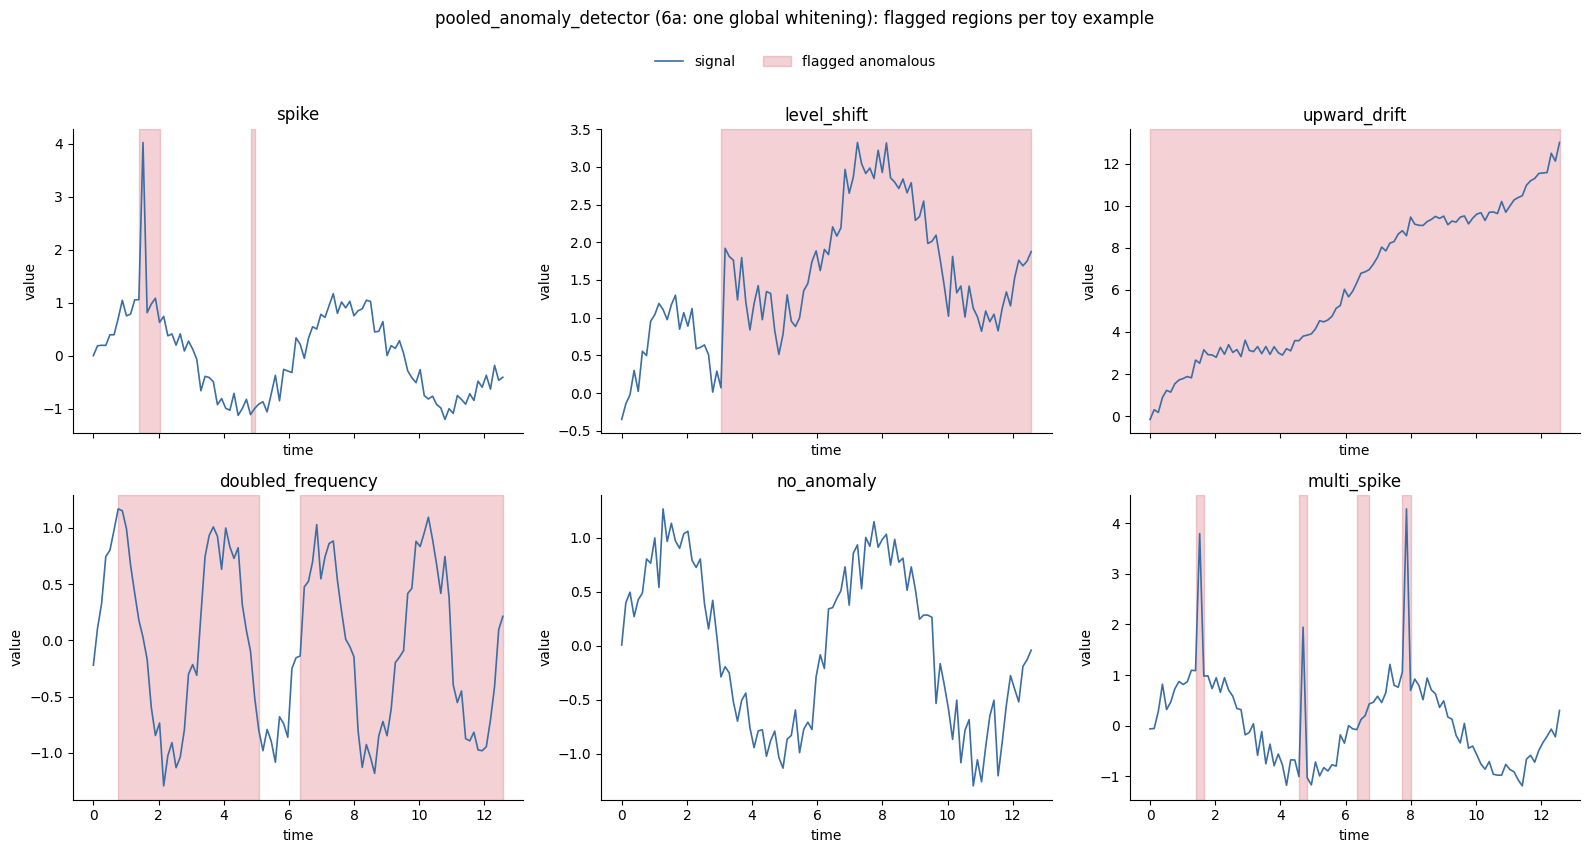

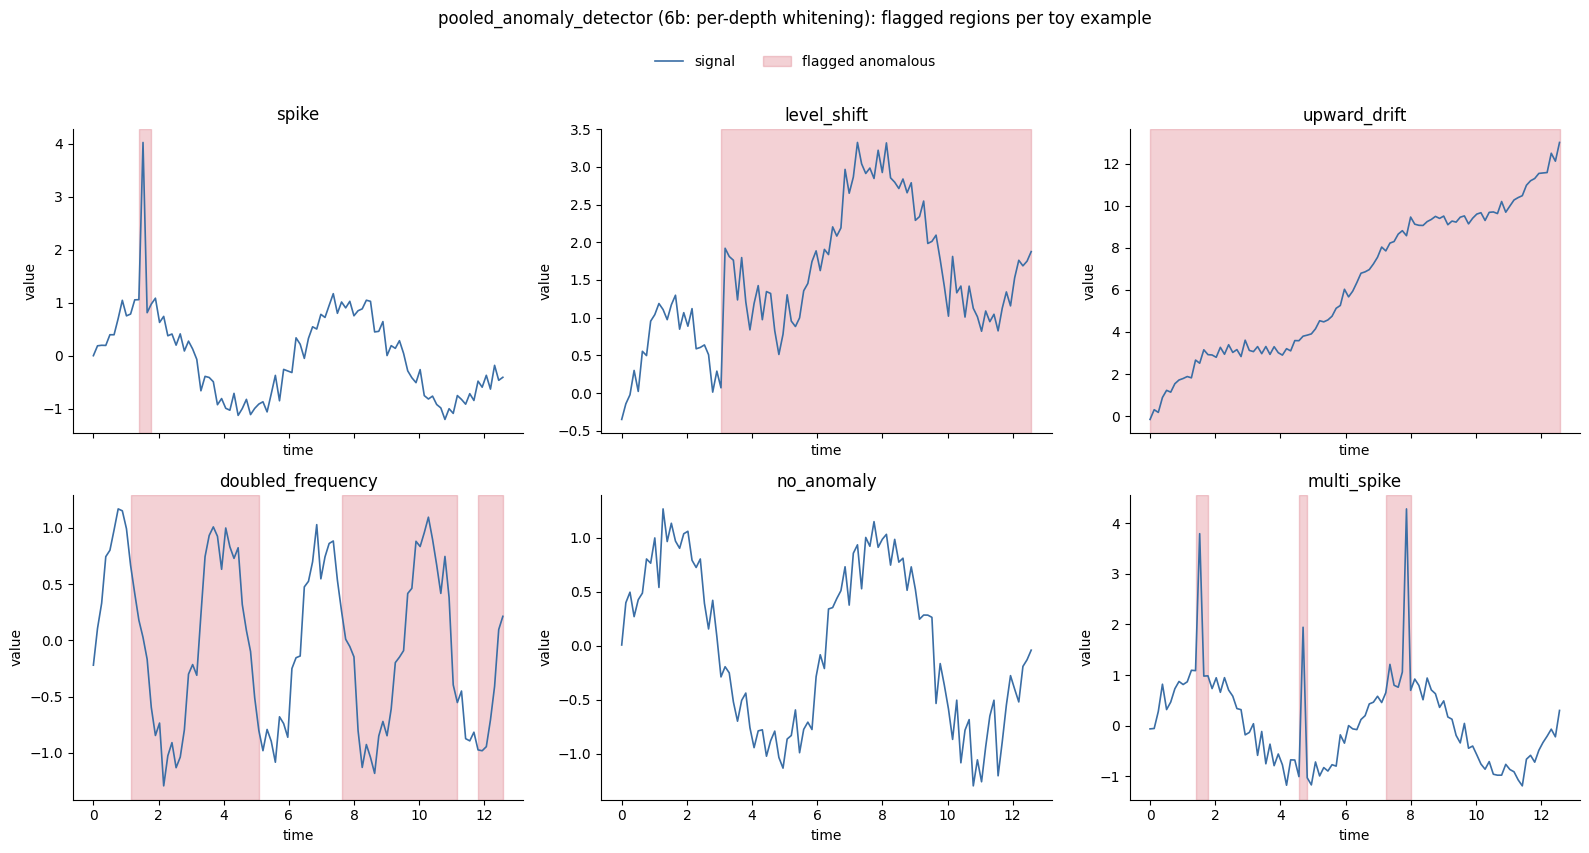

stream              Sec 4 windows         Sec 5 per-interval    Sec 6a global         Sec 6b per-depth      
------------------------------------------------------------------------------------------------------------
spike               1 span(s),  12.5%     1 span(s),   2.0%     2 span(s),   6.1%     1 span(s),   3.0%     
level_shift         1 span(s),  75.0%     1 span(s),  75.8%     1 span(s),  75.8%     1 span(s),  75.8%     
upward_drift        1 span(s), 100.0%     1 span(s), 100.0%     1 span(s), 100.0%     1 span(s), 100.0%     
doubled_frequency   1 span(s), 100.0%     2 span(s),  70.7%     2 span(s),  83.8%     3 span(s),  65.7%     
no_anomaly          0 span(s),   0.0%     0 span(s),   0.0%     0 span(s),   0.0%     0 span(s),   0.0%     
multi_spike         3 span(s),  37.5%     3 span(s),   6.1%     4 span(s),   9.1%     3 span(s),  11.1%     

6a and 6b produce identical flagged spans: False
  spike:
    6a [(1.3962634015954636, 2.0309285841388562), (4.823455387329783,

In [22]:
# Flagged regions for both pooled variants, same layout/convention as Sections 4 and 5
for label, results in [('6a: one global whitening', results_6a),
                       ('6b: per-depth whitening', results_6b)]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    axes = axes.ravel()

    for ax, anomaly_type in zip(axes, anomaly_order):
        stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
        ax.plot(stream_df['time'].to_numpy(), stream_df['output'].to_numpy(),
                color=line_color, linewidth=1.2, label='signal')
        for j, (start, end) in enumerate(merge_intervals(results[anomaly_type])):
            ax.axvspan(start, end, color=flag_color, alpha=0.25,
                       label='flagged anomalous' if j == 0 else None)
        ax.set_title(anomaly_type)
        ax.set_xlabel('time')
        ax.set_ylabel('value')
        ax.spines[['top', 'right']].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02))
    fig.suptitle('pooled_anomaly_detector ({0}): flagged regions per toy example'.format(label),
                 y=1.06)
    plt.tight_layout()
    plt.show()


# Four-way comparison: spans flagged and total time coverage
def coverage(intervals):
    return sum(end - start for start, end in merge_intervals(intervals)) / (4 * np.pi) * 100

variants = [('Sec 4 windows', window_results),
            ('Sec 5 per-interval', pysegments_results),
            ('Sec 6a global', results_6a),
            ('Sec 6b per-depth', results_6b)]

print('{0:<20}'.format('stream') + ''.join('{0:<22}'.format(name) for name, _ in variants))
print('-' * (20 + 22 * len(variants)))
for anomaly_type in anomaly_order:
    row = '{0:<20}'.format(anomaly_type)
    for _name, results in variants:
        spans = len(merge_intervals(results[anomaly_type]))
        row += '{0:<22}'.format('{0} span(s), {1:5.1f}%'.format(
            spans, coverage(results[anomaly_type])))
    print(row)

# Do 6a and 6b actually disagree anywhere?
print()
identical = all(merge_intervals(results_6a[a]) == merge_intervals(results_6b[a])
                for a in anomaly_order)
print('6a and 6b produce identical flagged spans:', identical)
if not identical:
    for anomaly_type in anomaly_order:
        a, b = merge_intervals(results_6a[anomaly_type]), merge_intervals(results_6b[anomaly_type])
        if a != b:
            print('  {0}:\n    6a {1}\n    6b {2}'.format(anomaly_type, a, b))

**Per-depth whitening is clearly faster and mostly more accurate, but the accuracy result is now mixed rather than a clean sweep.**

## Accuracy: 6a invents anomalies, 6b fragments one

`level_shift`, `upward_drift` and `no_anomaly` are identical under both. The three harder streams split the verdict:

| stream | 6a (global) | 6b (per-depth) | better |
|---|---|---|---|
| `spike` | **2 spans**, 6.1% — the true one plus a spurious (4.82, 4.95) | 1 span, 3.0%, (1.40, 1.78) | **6b** |
| `multi_spike` | **4 spans**, 9.1% — all three spikes plus a spurious (6.35, 6.73) | 3 spans, 11.1%, one per spike | **6b** |
| `doubled_frequency` | 2 spans, **83.8%** | 3 spans, 65.7% | **6a** |

`spike` contains exactly one spike, at `t = pi/2`; `multi_spike` has three, at `pi/2`, `3pi/2`, `5pi/2`. 6a's extra spans fall in genuinely clean stretches, so the global whitening does not merely blur localization — it invents anomalies that are not there. `no_anomaly` still comes back empty under both, so 6a is not indiscriminate; it goes wrong specifically on streams that already contain an anomaly elsewhere, consistent with one badly-scaled direction dominating the distance once anything has perturbed the corpus statistics.

The exception is `doubled_frequency`, where 6a covers substantially more of a stream that genuinely is anomalous throughout, and 6b fragments its answer into three spans separated by gaps it wrongly considers clean. This is the one stream where nothing in the notebook has ever done well, and it remains the best target for further work.

## The rank prediction was wrong, in an informative way

Section 6a above flagged retained rank as the thing to watch, reasoning that a covariance fitted across widths from 99 points down to 1 would be dominated by the widest intervals and discard the directions describing the narrow ones. **That did not happen.** The global whitening retains the full 62 of 62 directions.

The rank deficiency is in the *other* variant, and at the *wide* end:

```
depth 0 (median width 99)   rank 57 of 62
depth 1 (median width 50)   rank 58 of 62
depth 2 (median width 25)   rank 60 of 62
depth 3 (median width 12)   rank 62 of 62
depth 4 (median width  6)   rank 62 of 62
depth 5 (median width  3)   rank 62 of 62
```

That pattern is about **sample diversity, not scale**. Depth 0 contains one interval per stream — the same full range, 10,000 times, over near-identical noisy sines — so the data genuinely occupies fewer than 62 independent directions and `rcond` correctly drops the rest. Deeper levels contribute many distinct intervals covering different parts of the cycle, so the spanned subspace fills out and the rank reaches 62. Pooling every depth together gives the global fit maximal diversity, which is exactly why it keeps full rank.

So full rank is not the same as a well-scaled basis. 6a retains every direction and still whitens narrow intervals against a covariance whose variance budget is set by the wide ones — which is the mechanism behind its false positives, and it would have been invisible had we only checked the rank.

## Speed: laziness favours per-depth, and this comparison is the reliable one

6a builds 1 whitening and 1 FAISS index; 6b builds 6 of each — and 6b is still the faster of the two, by about 20%. The reason is which rows each fit has to touch. With `sig_tol=2` the search never tests an interval narrower than 4 points, so it never visits depths 6 and 7 — and those two depths hold 1,340,000 of the 1,970,000 pooled vectors, **68% of the pool**. 6b's six per-depth fits therefore process only about 630,000 rows in total, while 6a's single global fit must fold in all 1,970,000. Building one index instead of six does not recover that.

That disadvantage is structural rather than incidental: the deeper the tree, the larger the fraction of the pool that sits below the search's resolution floor, and the more a global fit pays for data no query will ever use.

**A caveat on all other timings in this notebook.** Absolute measurements here are dominated by machine load, not by the algorithms. Section 5's per-interval rebuild has measured 71.7s, 39.2s and 20.5s across three runs of *identical* code — a 3.5x swing. Any Section 5 versus Section 6 comparison is therefore uninformative, and earlier conclusions drawn from it should be discounted. The 6a-versus-6b gap is trustworthy precisely because the two are measured back to back within a single run, and it has reproduced consistently (49.7 vs 40.1, then 48.4 vs 39.7).

The pooled approach's real advantage remains asymptotic and untested here: Section 5's per-candidate cost scales with corpus size, while 6a/6b's does not, and the pool build amortizes across every stream tested thereafter.

## Memory is the one place 6a is genuinely ahead

6a holds one 62 MB index against 6b's six (~372 MB). If the reference subsample had to be larger, or the machine tighter, that gap would matter and 6a might be the only variant that fits. On this hardware it did not bind — but it is the reason to keep 6a rather than deleting it as the losing arm.

## Nearest neighbours still come mostly from other depths

Same-depth fractions are 46/11/0/28/100/36% for 6a and 26/3/0/13/100/30% for 6b — low in both, and if anything lower for the per-depth variant. Whitening per depth does not make same-scale neighbours win; the scale-matching is done entirely by the whitening, never by the neighbour selection. Restricting the search to same-depth intervals remains untested and is still the most promising outstanding change: it would shrink each index, remove cross-scale comparisons entirely, and is the natural companion to a per-depth whitening that has now twice been shown to matter.

Section 6c: a separate covariance per dyadic node

6a fits one whitening across the entire pool; 6b fits one per depth. Both still average over
every *position* at whatever scale they describe. At depth 3 there are eight nodes, and 6b
fits a single covariance from all eight pooled together - so an interval covering the sine's
rising edge and one covering its trough are treated as samples of the same distribution, even
though on a periodic signal they are systematically different shapes.

**6c takes the obvious next step: one covariance per dyadic node.** For the node spanning
points (24, 36), the whitening is fitted from exactly the 10,000 corpus intervals spanning
(24, 36) - one per corpus stream - and from nothing else.

Everything else is held fixed. The searchable reference is still the whole pool, the same
250,000-vector subsample 6a and 6b use, shared via `share_from` so all three sections are
compared on byte-identical data. Only the coordinates that reference is measured in change,
and they now change per node rather than per depth.

This is the same move Section 5 made per candidate interval, but paid for once per *node*
rather than once per *query*, and scored against the full pooled reference rather than a
corpus restricted to the interval.

Two things to watch, and they point in opposite directions:

- **Statistically it is the best-conditioned of the three.** Each node's covariance is fitted
  from 10,000 intervals of identical width and identical position, in 62 dimensions - an N/D
  of 161. 6a's single fit had to describe widths spanning two orders of magnitude at once,
  and `report_whitening` has been showing what that costs in retained rank.
- **Computationally it is the worst.** The reference is whitened *by* the metric, so a new
  metric means a new 250,000-vector index. 6a builds one index and reuses it everywhere; 6b
  builds one per depth, about six; 6c builds one per node the search visits. They cannot all
  stay resident - 62 MB each - so `index_cache_size` bounds how many are kept and the rest
  are rebuilt on demand.

In [23]:
# Section 6c: the same pool once more, but a separate covariance per dyadic node.
# `share_from` reuses 6a's pooled arrays and reference subsample, so 6a, 6b and 6c differ in
# the whitening and in nothing else.
t0 = time.perf_counter()
reference_6c = PooledDyadicReference(
    share_from=reference_6a, whitening='per_interval', threshold_percentile=95,
    index_cache_size=16,
)
print('reference built in {0:.3f}s (pool reused from 6a)'.format(time.perf_counter() - t0))
print('pool is the same object: {0}'.format(reference_6c.pooled is reference_6a.pooled))

# The pool's block layout is what makes a per-node covariance addressable as a slice at all:
# pooled[d] is depth d's nodes concatenated in `intervals[d]` order, n_corpus rows each.
print('\n{0:>6}  {1:>6}  {2:>16}  {3:>14}'.format(
    'depth', 'nodes', 'rows per node', 'pooled rows'))
for d in sorted(reference_6c.pooled)[:6]:
    n_nodes = len(reference_6c.intervals[d])
    assert reference_6c.pooled[d].shape[0] == n_nodes * reference_6c.n_corpus, \
        'block layout is not nodes x streams at depth {0}'.format(d)
    print('{0:>6}  {1:>6}  {2:>16,}  {3:>14,}'.format(
        d, n_nodes, reference_6c.n_corpus, reference_6c.pooled[d].shape[0]))

# A node's covariance sees one interval per corpus stream, at one width and one position.
example_depth = 3
example_node = 2
lo_e, hi_e = reference_6c.intervals[example_depth][example_node]
print('\nexample: depth {0}, node {1} spans points ({2}, {3}) - covariance fitted from {4} '
      'intervals'.format(example_depth, example_node, lo_e, hi_e,
                         reference_6c.node_pool(example_depth, example_node).shape[0]))
print('6b would fit that depth from all {0:,} intervals at depth {1}, pooling its {2} nodes'
      .format(reference_6c.pooled[example_depth].shape[0], example_depth,
              len(reference_6c.intervals[example_depth])))

reference built in 0.000s (pool reused from 6a)
pool is the same object: True

 depth   nodes     rows per node     pooled rows
     0       1            10,000          10,000
     1       2            10,000          20,000
     2       4            10,000          40,000
     3       8            10,000          80,000
     4      16            10,000         160,000
     5      32            10,000         320,000

example: depth 3, node 2 spans points (24, 36) - covariance fitted from 10000 intervals
6b would fit that depth from all 80,000 intervals at depth 3, pooling its 8 nodes


In [24]:
# Run the detector against 6c's per-node whitened reference
results_6c = {}
t0 = time.perf_counter()

for anomaly_type in anomaly_order:
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    intervals = pooled_anomaly_detector(
        stream_df['output'].to_numpy(), stream_df['time'].to_numpy(), reference_6c,
        max_depth=20, tol=0, sig_tol=2, verbose=True,
    )
    results_6c[anomaly_type] = intervals
    print(anomaly_type, '->', intervals)

elapsed_6c = time.perf_counter() - t0
print('\nSection 6c: {0:.2f}s for all six streams'.format(elapsed_6c))
report_whitening(reference_6c, 'Section 6c')

AD calls: 88 - nearest neighbour came from the query's own depth 19% of the time
spike -> [(0.7615982190520711, 2.792526803190927), (3.8079910952603555, 4.442656277803748), (6.981317007977318, 9.012245592116175)]


AD calls: 37 - nearest neighbour came from the query's own depth 8% of the time
level_shift -> [(0.7615982190520711, 12.566370614359172)]


AD calls: 34 - nearest neighbour came from the query's own depth 0% of the time
upward_drift -> [(0.0, 12.566370614359172)]


AD calls: 74 - nearest neighbour came from the query's own depth 5% of the time
doubled_frequency -> [(0.0, 5.07732146034714), (6.981317007977318, 11.423973285781067)]


AD calls: 1 - nearest neighbour came from the query's own depth 100% of the time
no_anomaly -> []


AD calls: 66 - nearest neighbour came from the query's own depth 20% of the time
multi_spike -> [(0.7615982190520711, 9.139178628624853)]

Section 6c: 150.34s for all six streams
Section 6c: 51 whitening matrix/matrices, 213 FAISS index/indices built
    51 dyadic node(s) visited, rank 57 to 57 of 62
    at most 16 index/indices resident at once, 213 built in total


In [25]:
# Three-way comparison of the pooled variants, on identical data
pooled_variants = [('6a global', results_6a, elapsed_6a),
                   ('6b per-depth', results_6b, elapsed_6b),
                   ('6c per-node', results_6c, elapsed_6c)]

print('{0:<20}'.format('stream') + ''.join('{0:<24}'.format(n) for n, _, _ in pooled_variants))
print('-' * (20 + 24 * len(pooled_variants)))
for anomaly_type in anomaly_order:
    row = '{0:<20}'.format(anomaly_type)
    for _name, results, _t in pooled_variants:
        row += '{0:<24}'.format('{0} span(s), {1:5.1f}%'.format(
            len(merge_intervals(results[anomaly_type])), coverage(results[anomaly_type])))
    print(row)

print('\n{0:<16}{1:>10}{2:>12}{3:>16}'.format(
    'variant', 'seconds', 'whitenings', 'indices built'))
for (name, _r, seconds), ref in zip(pooled_variants,
                                    [reference_6a, reference_6b, reference_6c]):
    print('{0:<16}{1:>10.2f}{2:>12}{3:>16}'.format(
        name, seconds, len(ref._L_inv), ref._index_builds))

print('\nno_anomaly coverage (false positives): ' + ', '.join(
    '{0} {1:.1f}%'.format(name, coverage(results['no_anomaly']))
    for name, results, _t in pooled_variants))

# Do the three ever disagree?
print()
for name, results, _t in pooled_variants[1:]:
    same = all(merge_intervals(results[a]) == merge_intervals(results_6a[a])
               for a in anomaly_order)
    print('{0} identical to 6a on every stream: {1}'.format(name, same))

stream              6a global               6b per-depth            6c per-node             
--------------------------------------------------------------------------------------------
spike               2 span(s),   6.1%       1 span(s),   3.0%       3 span(s),  37.4%       
level_shift         1 span(s),  75.8%       1 span(s),  75.8%       1 span(s),  93.9%       
upward_drift        1 span(s), 100.0%       1 span(s), 100.0%       1 span(s), 100.0%       
doubled_frequency   2 span(s),  83.8%       3 span(s),  65.7%       2 span(s),  75.8%       
no_anomaly          0 span(s),   0.0%       0 span(s),   0.0%       0 span(s),   0.0%       
multi_spike         4 span(s),   9.1%       3 span(s),  11.1%       1 span(s),  66.7%       

variant            seconds  whitenings   indices built
6a global            48.64           1               1
6b per-depth         46.90           6               6
6c per-node         150.34          51             213

no_anomaly coverage (false positiv

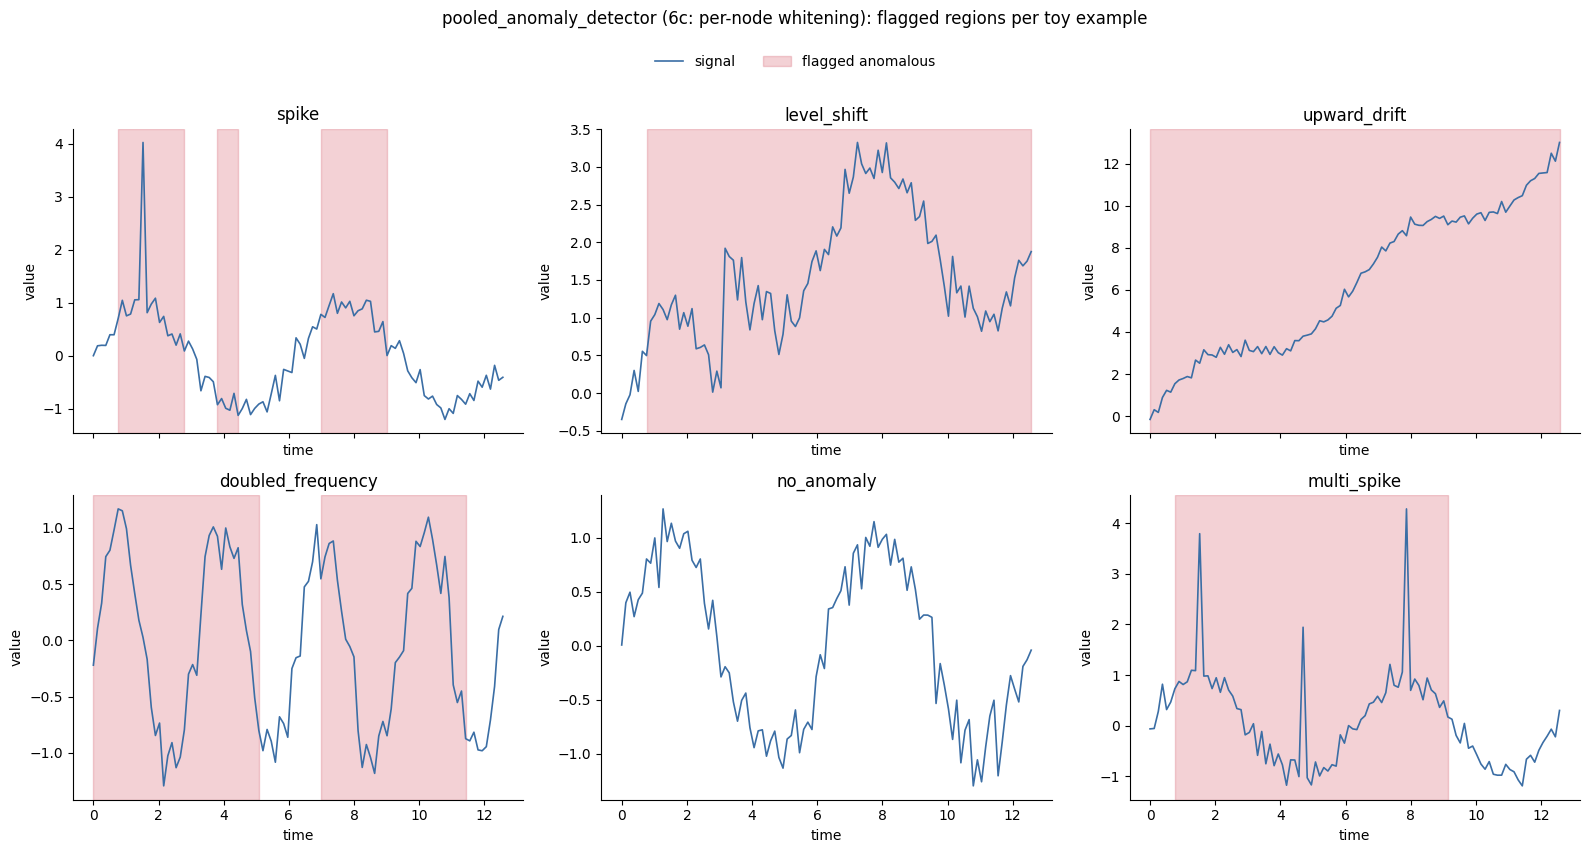

In [26]:
# Flagged regions for the per-node variant, same layout/convention as 6a and 6b
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for ax, anomaly_type in zip(axes, anomaly_order):
    stream_df = toy_anomalies[toy_anomalies['anomaly_type'] == anomaly_type]
    ax.plot(stream_df['time'].to_numpy(), stream_df['output'].to_numpy(),
            color=line_color, linewidth=1.2, label='signal')
    for j, (start, end) in enumerate(merge_intervals(results_6c[anomaly_type])):
        ax.axvspan(start, end, color=flag_color, alpha=0.25,
                   label='flagged anomalous' if j == 0 else None)
    ax.set_title(anomaly_type)
    ax.set_xlabel('time')
    ax.set_ylabel('value')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle('pooled_anomaly_detector (6c: per-node whitening): flagged regions per toy example',
             y=1.06)
plt.tight_layout()
plt.show()

**6c is the most specific metric of the three and the worst detector of the three, and the
reason is instructive.**

Recall the ground truth: `spike` is a single perturbed point at t = pi/2 ~ 1.571,
`multi_spike` is three points at pi/2, 3pi/2 ~ 4.712 and 5pi/2 ~ 7.854, `level_shift` begins
at t > pi ~ 3.142, and `upward_drift` and `doubled_frequency` are anomalous throughout.

| stream | 6a global | 6b per-depth | 6c per-node |
|---|---|---|---|
| `spike` | (1.40, 2.03) hit + one false span, 6.1% | **(1.40, 1.78), one tight hit, 3.0%** | (0.76, 2.79) hit + **two** false spans, 37.4% |
| `multi_spike` | 3 hits + 1 false, 9.1% | **all 3 hits, no false, 11.1%** | one blob (0.76, 9.14) swallowing all three, 66.7% |
| `level_shift` | (3.05, 12.57), true start 3.14 | (3.05, 12.57) | (0.76, 12.57) - starts 2.4 units early |
| `doubled_frequency` | 83.8% | 65.7% | 75.8% |
| `no_anomaly` | 0% | 0% | 0% |

No variant produces a false positive on the negative control, so nothing here is a threshold
that has simply come loose. What collapses in 6c is **localisation**: it still finds every
anomaly, but brackets each one far too widely, invents two spurious regions on `spike`, and
merges `multi_spike`'s three well-separated spikes into a single span covering two thirds of
the stream. 6b's ability to return three clean, separate spans is exactly what 6c loses.

**Why the best-conditioned covariance gives the worst answer.** Two measurements in the
output above explain it.

First, `report_whitening` shows every per-node whitening retains **rank 57 of 62**, whereas
6b's per-depth fits retain 57, 58, 60, 62, 62, 62 as the intervals get narrower. Fitting from
a single node is *more* degenerate, not less: 10,000 intervals of identical width at an
identical position span fewer directions than the same 10,000 spread over the eight positions
at that depth. So the per-node whitening divides by more near-null directions, and inflates
distances along axes where the corpus has no real variation.

Second, and more fundamentally, look at how often the nearest neighbour came from the query's
own depth: **19%, 8%, 0%, 5%, 100%, 20%** for 6c, against 46%, 11%, 0%, 28%, 100%, 36% for
6a. The metric is fitted to one node's 10,000 intervals, but the reference set it is applied
to is the whole 250,000-vector pool - about 99.5% of which are intervals from *other* nodes
and other depths. Whitening by one node's covariance makes that node's intervals unit-variance
and distorts everything else, and since the returned neighbour usually comes from somewhere
else entirely, the distance actually being thresholded is mostly measuring foreign intervals
in coordinates fitted to a scale they do not belong to. 6c makes the metric maximally
specific while leaving the searchable set maximally general, and the two work against each
other.

That diagnosis has a clear implication: **specificity has to be applied to the metric and the
reference set together, or not at all.** Restricting only the metric (6c) is worse than
restricting it coarsely (6b) or not at all (6a). Section 5's per-interval detector restricts
both - it rebuilds the corpus *and* the covariance for each candidate - and it localises
`spike` and `multi_spike` better than 6c does despite using a corpus half the size. The
natural 6d, not run here, is 6c's per-node whitening searched against only that node's own
10,000 intervals.

**The cost is the worst of the three by a wide margin.** 150.3s against 48.6s for 6a and
46.9s for 6b, roughly 3x. The pool and the reference subsample are shared, so none of that is
build cost - it is that the reference is whitened *by* the metric, so every distinct metric
needs its own 250,000-vector index. 6a builds one index and reuses it for every query; 6b
builds six; 6c visited 51 distinct nodes and built **213** indices, because at 62 MB each
only 16 fit in `index_cache_size` and the search kept revisiting evicted nodes. Raising the
cache would trade memory for those rebuilds, but the underlying scaling - one index per
distinct metric - is what makes per-node whitening expensive over a pooled reference, and it
is the same reason Section 5's per-candidate rebuild was slow.

Section 7: A multimodal corpus — merged versus separate

Every corpus so far has been unimodal: 10,000 noisy sines around one base signal. Real reference data rarely looks like that. This section adds a second mode — noisy square waves of the same period, amplitude and noise level — and asks how the detector should be given two modes at once.

Two models, and the difference between them is where the "either mode is fine" logic lives:

- **Model 1 — merged corpus.** Concatenate 5,000 sine and 5,000 square streams into one 10,000-stream corpus and run Sections 6a/6b unchanged. The bimodality is handled implicitly, by nearest-neighbour search: a square-wave test interval should find square-wave neighbours and score as normal, even though the corpus *mean* now sits between the two modes and describes neither. This is the case where nearest-neighbour scoring should beat any method that models the corpus as a single Gaussian — worth checking rather than assuming, since the Mahalanobis whitening in front of the kNN search *is* fitted as a single Gaussian.
- **Model 2 — separate corpora.** Keep the two references apart, score every test stream against each, and report **both** answers rather than reducing them to one flag. No combination rule is imposed here; the point is to see what each mode individually considers anomalous, which a merged corpus averages away.

Both models use both whitening modes from Sections 6a and 6b, giving four configurations in total (six detector runs per stream, since Model 2 runs twice).

The test set grows from 6 streams to 13: the six sine anomalies from Section 1, square-wave counterparts of all six built with identical anomaly magnitudes and positions, and one **mode-switch** stream that is a clean sine for the first half and a clean square for the second. That last one is the interesting case. Against a corpus containing both modes, each half is individually unremarkable — so anything flagged there reflects the model's view of the *switch*, not of either waveform. No ground truth is asserted for it; the behaviour is reported and discussed.

Both `no_anomaly` streams matter more than they did before. With two modes in play, a clean square wave is a genuine negative for a merged corpus but a genuine positive for a sine-only one, so the false-positive question finally has more than one sample behind it.

A note on memory: each pooled corpus is a few hundred MB and this machine has 7.8 GB, so the references are built and released one at a time rather than all being held simultaneously. That is why `del` and `gc.collect()` appear between the stages below.

sine corpus:   (10000, 100)
square corpus: (10000, 100)

test set: 13 streams, 1300 rows


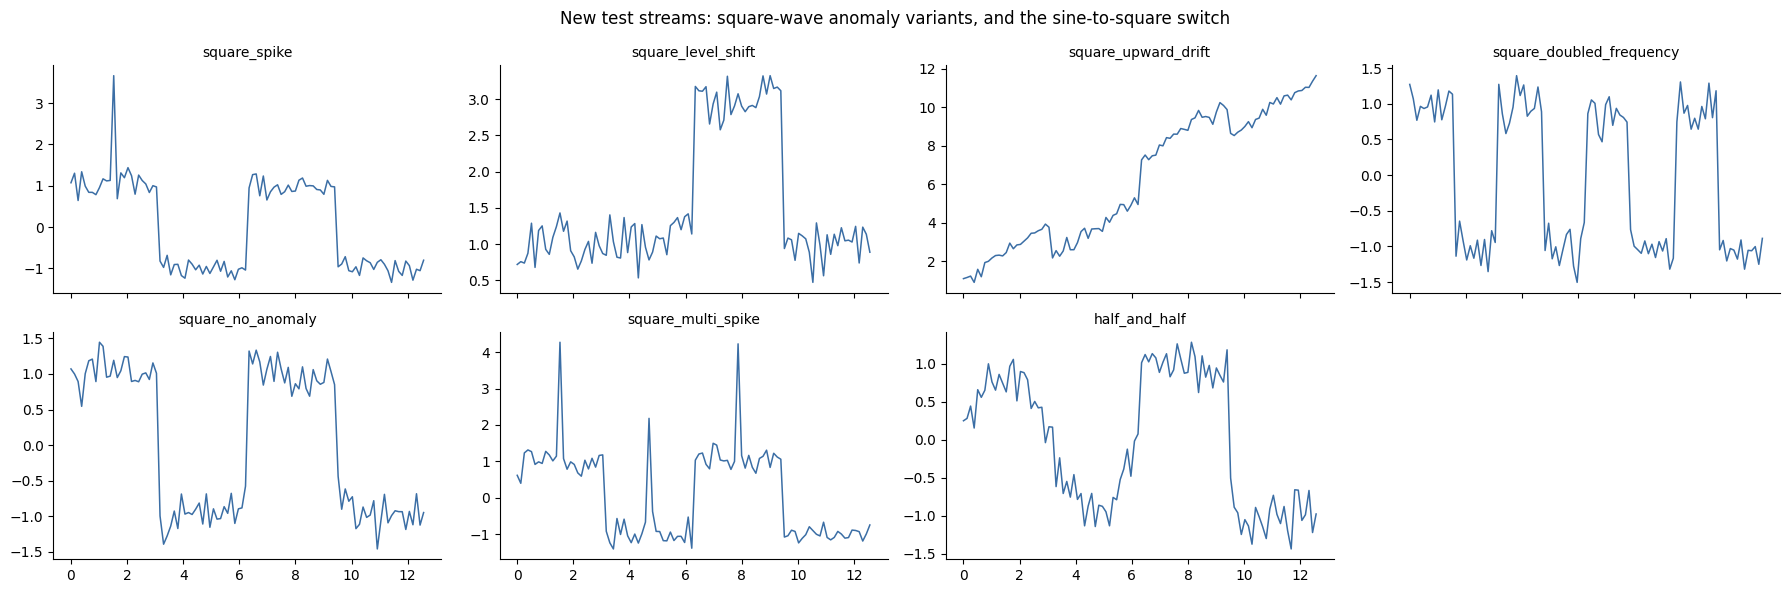

In [27]:
#=================================================================================================================================
# A second mode: noisy square waves, and square-wave counterparts of every toy anomaly
#=================================================================================================================================

def square_wave(x):
    """Unit-amplitude square wave with period 2*pi - the same period as the sine corpus, so
    both modes complete two cycles over the notebook's 0..4*pi range.

    np.where rather than np.sign because sign(0) is 0, which would put a spurious third level
    into the wave exactly at the zero crossings.
    """
    return np.where(np.sin(x) >= 0, 1.0, -1.0)


square_base = square_wave(t)
rng_square_corpus = np.random.default_rng(43)
square_corpus = square_base[None, :] + rng_square_corpus.normal(0, CORPUS_NOISE,
                                                                size=(n_streams, length))
print('sine corpus:  ', corpus.shape)
print('square corpus:', square_corpus.shape)

# Square-wave counterparts of the Section 1 anomalies - same magnitudes, same positions,
# same noise level, so the only difference from their sine versions is the base waveform.
rng_sq = {name: np.random.default_rng(seed) for name, seed in [
    ('spike', 21), ('level_shift', 22), ('upward_drift', 23), ('doubled_frequency', 24),
    ('no_anomaly', 25), ('multi_spike', 26), ('half_and_half', 27)]}

sq_spike = square_base + rng_sq['spike'].normal(0, CORPUS_NOISE, size=len(t))
sq_spike[spike_index] += 3.0

sq_level_shift = square_base + rng_sq['level_shift'].normal(0, CORPUS_NOISE, size=len(t))
sq_level_shift[shift_start:] += 2.0

sq_upward_drift = t + square_base + rng_sq['upward_drift'].normal(0, CORPUS_NOISE, size=len(t))

sq_doubled_frequency = square_wave(2 * t) + rng_sq['doubled_frequency'].normal(0, CORPUS_NOISE,
                                                                              size=len(t))

sq_no_anomaly = square_base + rng_sq['no_anomaly'].normal(0, CORPUS_NOISE, size=len(t))

sq_multi_spike = square_base + rng_sq['multi_spike'].normal(0, CORPUS_NOISE, size=len(t))
for idx in (spike_index, multi_spike_index, multi_spike_index2):
    sq_multi_spike[idx] += 3.0

# The mode-switch stream: a clean sine for the first half, a clean square for the second.
# Under a corpus containing both modes each half is individually unremarkable, so whatever
# gets flagged here is the model's view of the switch itself rather than of either waveform.
half_and_half = (np.where(t < 2 * np.pi, np.sin(t), square_base)
                 + rng_sq['half_and_half'].normal(0, CORPUS_NOISE, size=len(t)))

# --- assemble the 13-stream test set --------------------------------------------------
square_streams = [
    ('spike', sq_spike), ('level_shift', sq_level_shift), ('upward_drift', sq_upward_drift),
    ('doubled_frequency', sq_doubled_frequency), ('no_anomaly', sq_no_anomaly),
    ('multi_spike', sq_multi_spike),
]

frames, multimodal_order = [], []
for name in anomaly_order:                      # the six sine streams from Section 1
    s = toy_anomalies[toy_anomalies['anomaly_type'] == name]
    label = 'sine_' + name
    frames.append(pd.DataFrame({'time': s['time'].to_numpy(),
                                'output': s['output'].to_numpy(), 'stream': label}))
    multimodal_order.append(label)

for name, values in square_streams:
    label = 'square_' + name
    frames.append(pd.DataFrame({'time': t, 'output': values, 'stream': label}))
    multimodal_order.append(label)

frames.append(pd.DataFrame({'time': t, 'output': half_and_half, 'stream': 'half_and_half'}))
multimodal_order.append('half_and_half')

multimodal_tests = pd.concat(frames, ignore_index=True)
print('\ntest set:', len(multimodal_order), 'streams,', multimodal_tests.shape[0], 'rows')

# Subsets used by both models, drawn once so Model 1 and Model 2 see identical data.
# 5,000 per mode makes Model 1's merged corpus 10,000 streams - the same size Sections 6a
# and 6b used, so its pooled memory footprint is directly comparable. Clamped to whatever
# the corpora actually hold, so the cell still runs if n_streams is reduced.
MULTIMODAL_N = min(5000, corpus.shape[0], square_corpus.shape[0])
mm_rng = np.random.default_rng(0)
sine_subset = corpus[mm_rng.choice(corpus.shape[0], size=MULTIMODAL_N, replace=False)]
square_subset = square_corpus[mm_rng.choice(square_corpus.shape[0], size=MULTIMODAL_N,
                                            replace=False)]

# --- what the new streams look like ---------------------------------------------------
new_labels = ['square_' + n for n, _ in square_streams] + ['half_and_half']
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharex=True)
for ax, label in zip(axes.ravel(), new_labels):
    s = multimodal_tests[multimodal_tests['stream'] == label]
    ax.plot(s['time'].to_numpy(), s['output'].to_numpy(), color=line_color, linewidth=1.1)
    ax.set_title(label, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
axes.ravel()[-1].axis('off')
fig.suptitle('New test streams: square-wave anomaly variants, and the sine-to-square switch')
plt.tight_layout()
plt.show()

In [28]:
#=================================================================================================================================
# Model 1: one merged corpus holding both modes, scored exactly as in Sections 6a / 6b
#=================================================================================================================================
import gc

merged_corpus = np.concatenate([sine_subset, square_subset], axis=0)
print('merged corpus:', merged_corpus.shape,
      '({0:,} sine + {1:,} square)'.format(MULTIMODAL_N, MULTIMODAL_N))


def run_over_tests(reference, label):
    """Run `pooled_anomaly_detector` over every multimodal test stream. Reused by Model 2.

    `verbose=False` here: 13 streams x 6 configurations would otherwise emit 78 lines of
    per-stream diagnostics and bury the results.
    """
    out = {}
    t0 = time.perf_counter()
    for name in multimodal_order:
        s = multimodal_tests[multimodal_tests['stream'] == name]
        out[name] = pooled_anomaly_detector(
            s['output'].to_numpy(), s['time'].to_numpy(), reference,
            max_depth=20, tol=0, sig_tol=2)
    print('  {0:<44} {1:6.1f}s'.format(label, time.perf_counter() - t0))
    return out


print('\nrunning:')
merged_global = PooledDyadicReference(
    merged_corpus, t_corpus, trunc=TRUNC, max_depth=20,
    nn_reference_size=250_000, test_size=0.05, threshold_percentile=95,
    random_state=0, whitening='global')
results_merged_global = run_over_tests(merged_global, 'Model 1 merged, global whitening')

merged_perdepth = PooledDyadicReference(share_from=merged_global, whitening='per_depth',
                                        threshold_percentile=95)
results_merged_perdepth = run_over_tests(merged_perdepth, 'Model 1 merged, per-depth whitening')

report_whitening(merged_global, '\nModel 1 global')
report_whitening(merged_perdepth, 'Model 1 per-depth')

# Release before Model 2 builds its own pools. Each pooled corpus is a few hundred MB and
# this machine has 7.8 GB total, so the sections are deliberately run one pool at a time
# rather than holding every reference simultaneously.
del merged_global, merged_perdepth, merged_corpus
gc.collect()
print('\nmerged references released')

merged corpus: (10000, 100) (5,000 sine + 5,000 square)

running:


  Model 1 merged, global whitening               69.4s


  Model 1 merged, per-depth whitening            64.4s

Model 1 global: 1 whitening matrix/matrices, 1 FAISS index/indices built
    all depths pooled                  rank  62 of 62
Model 1 per-depth: 6 whitening matrix/matrices, 6 FAISS index/indices built
    depth 0 (median width 99)          rank  57 of 62
    depth 1 (median width 50)          rank  58 of 62
    depth 2 (median width 25)          rank  60 of 62
    depth 3 (median width 12)          rank  62 of 62
    depth 4 (median width 6)           rank  62 of 62
    depth 5 (median width 3)           rank  62 of 62



merged references released


In [29]:
#=================================================================================================================================
# Model 2: each corpus applied separately, both scores reported rather than combined
#=================================================================================================================================
# Each mode gets its own reference, and every test stream is run against both. No single
# flag is derived from the pair - the two answers are kept side by side, so the comparison
# below shows what each mode individually considers anomalous.
#
# Built and released one pool at a time, for the same memory reason as Model 1.

print('running:')

sine_global = PooledDyadicReference(
    sine_subset, t_corpus, trunc=TRUNC, max_depth=20,
    nn_reference_size=250_000, test_size=0.05, threshold_percentile=95,
    random_state=0, whitening='global')
results_sine_global = run_over_tests(sine_global, 'Model 2 vs sine corpus, global')

sine_perdepth = PooledDyadicReference(share_from=sine_global, whitening='per_depth',
                                      threshold_percentile=95)
results_sine_perdepth = run_over_tests(sine_perdepth, 'Model 2 vs sine corpus, per-depth')

del sine_global, sine_perdepth
gc.collect()

square_global = PooledDyadicReference(
    square_subset, t_corpus, trunc=TRUNC, max_depth=20,
    nn_reference_size=250_000, test_size=0.05, threshold_percentile=95,
    random_state=0, whitening='global')
results_square_global = run_over_tests(square_global, 'Model 2 vs square corpus, global')

square_perdepth = PooledDyadicReference(share_from=square_global, whitening='per_depth',
                                        threshold_percentile=95)
results_square_perdepth = run_over_tests(square_perdepth, 'Model 2 vs square corpus, per-depth')

del square_global, square_perdepth
gc.collect()
print('\nseparate references released')

running:


  Model 2 vs sine corpus, global                 48.0s


  Model 2 vs sine corpus, per-depth              43.0s


  Model 2 vs square corpus, global               40.7s


  Model 2 vs square corpus, per-depth            38.3s



separate references released


Percentage of each stream flagged anomalous

stream                         merged global   merged perdepth       sine global     sine perdepth     square global   square perdepth
--------------------------------------------------------------------------------------------------------------------------------------
sine_spike                              2.0%              2.0%              3.0%              3.0%             33.3%             35.4%
sine_level_shift                       75.8%             75.8%             75.8%             75.8%             83.8%             85.9%
sine_upward_drift                     100.0%             93.9%            100.0%            100.0%            100.0%             93.9%
sine_doubled_frequency                 59.6%             56.6%             66.7%             69.7%             83.8%             75.8%
sine_no_anomaly                         0.0%              0.0%              0.0%              0.0%             25.3%             41.4%
sine_multi

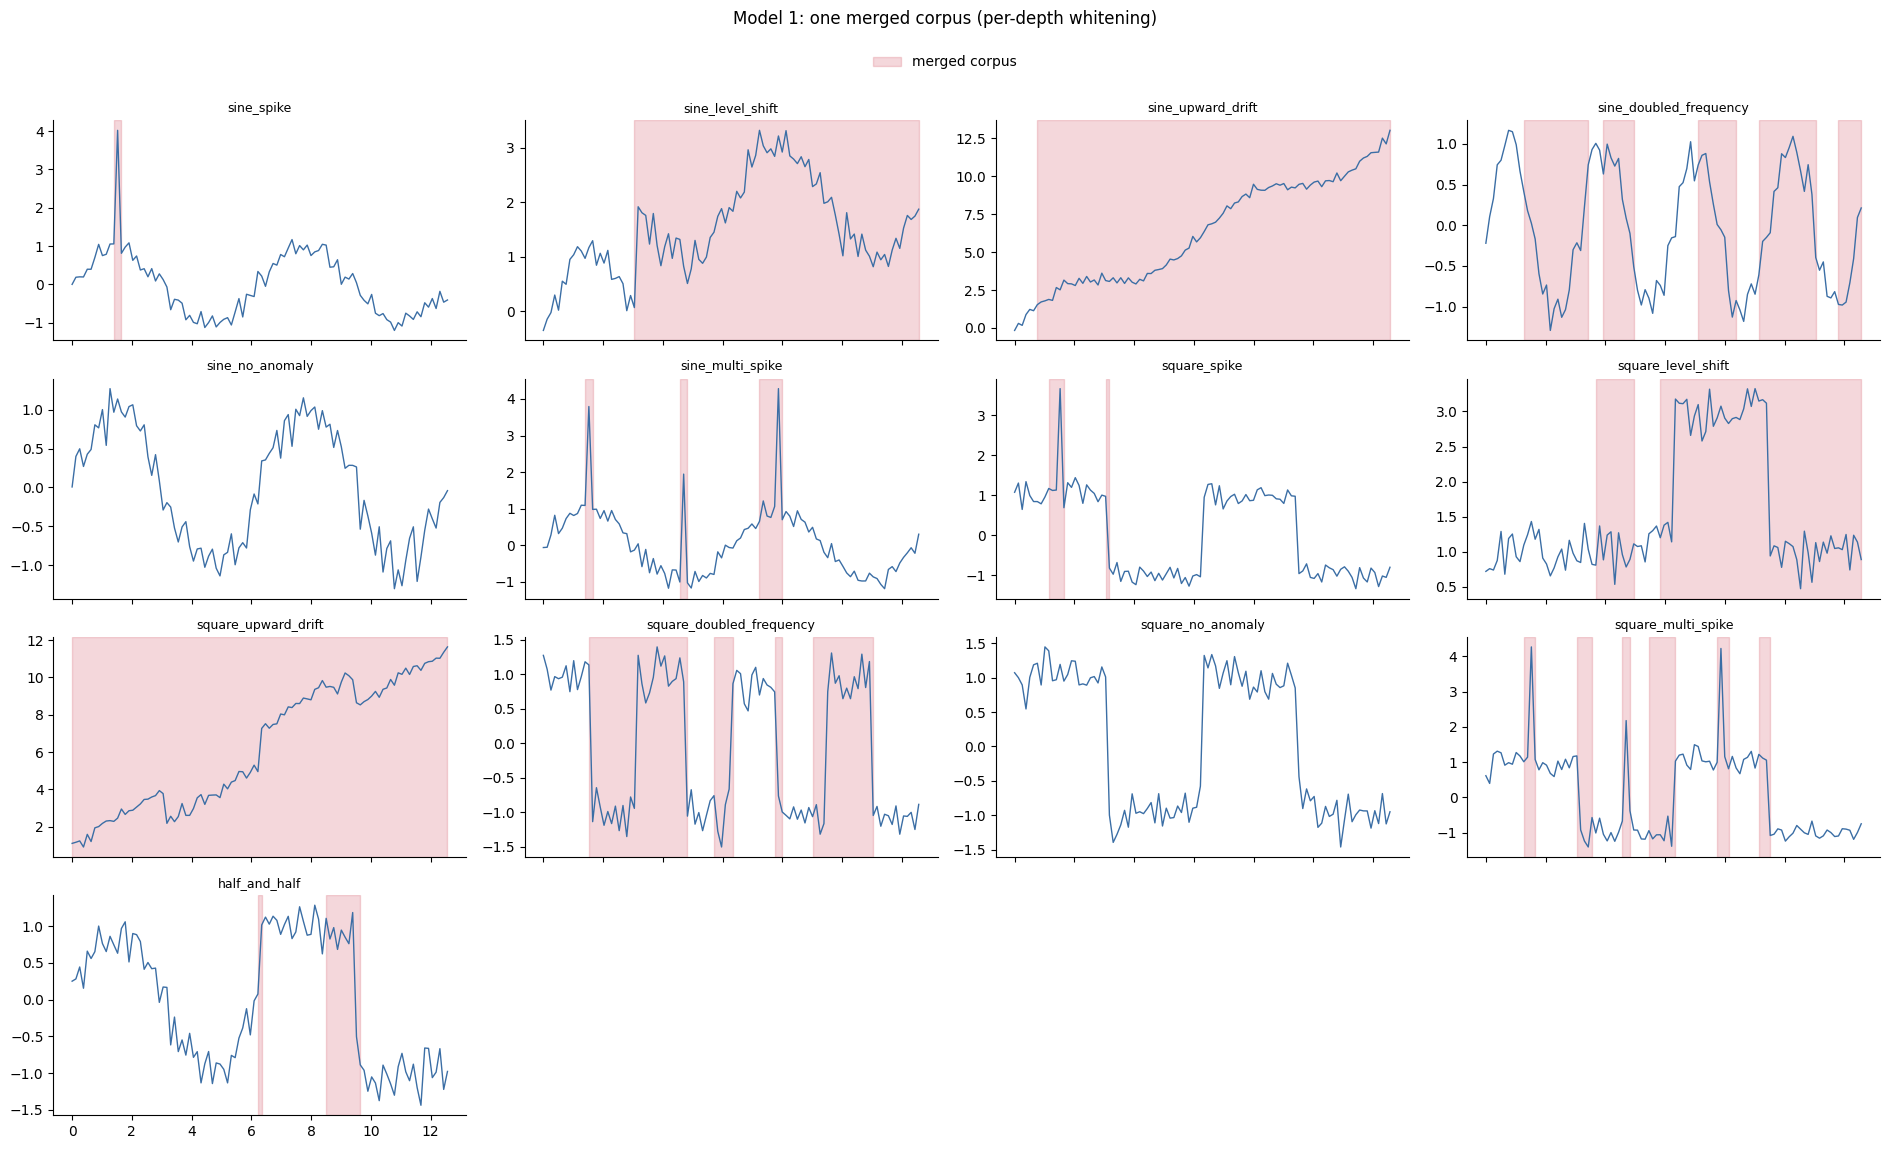

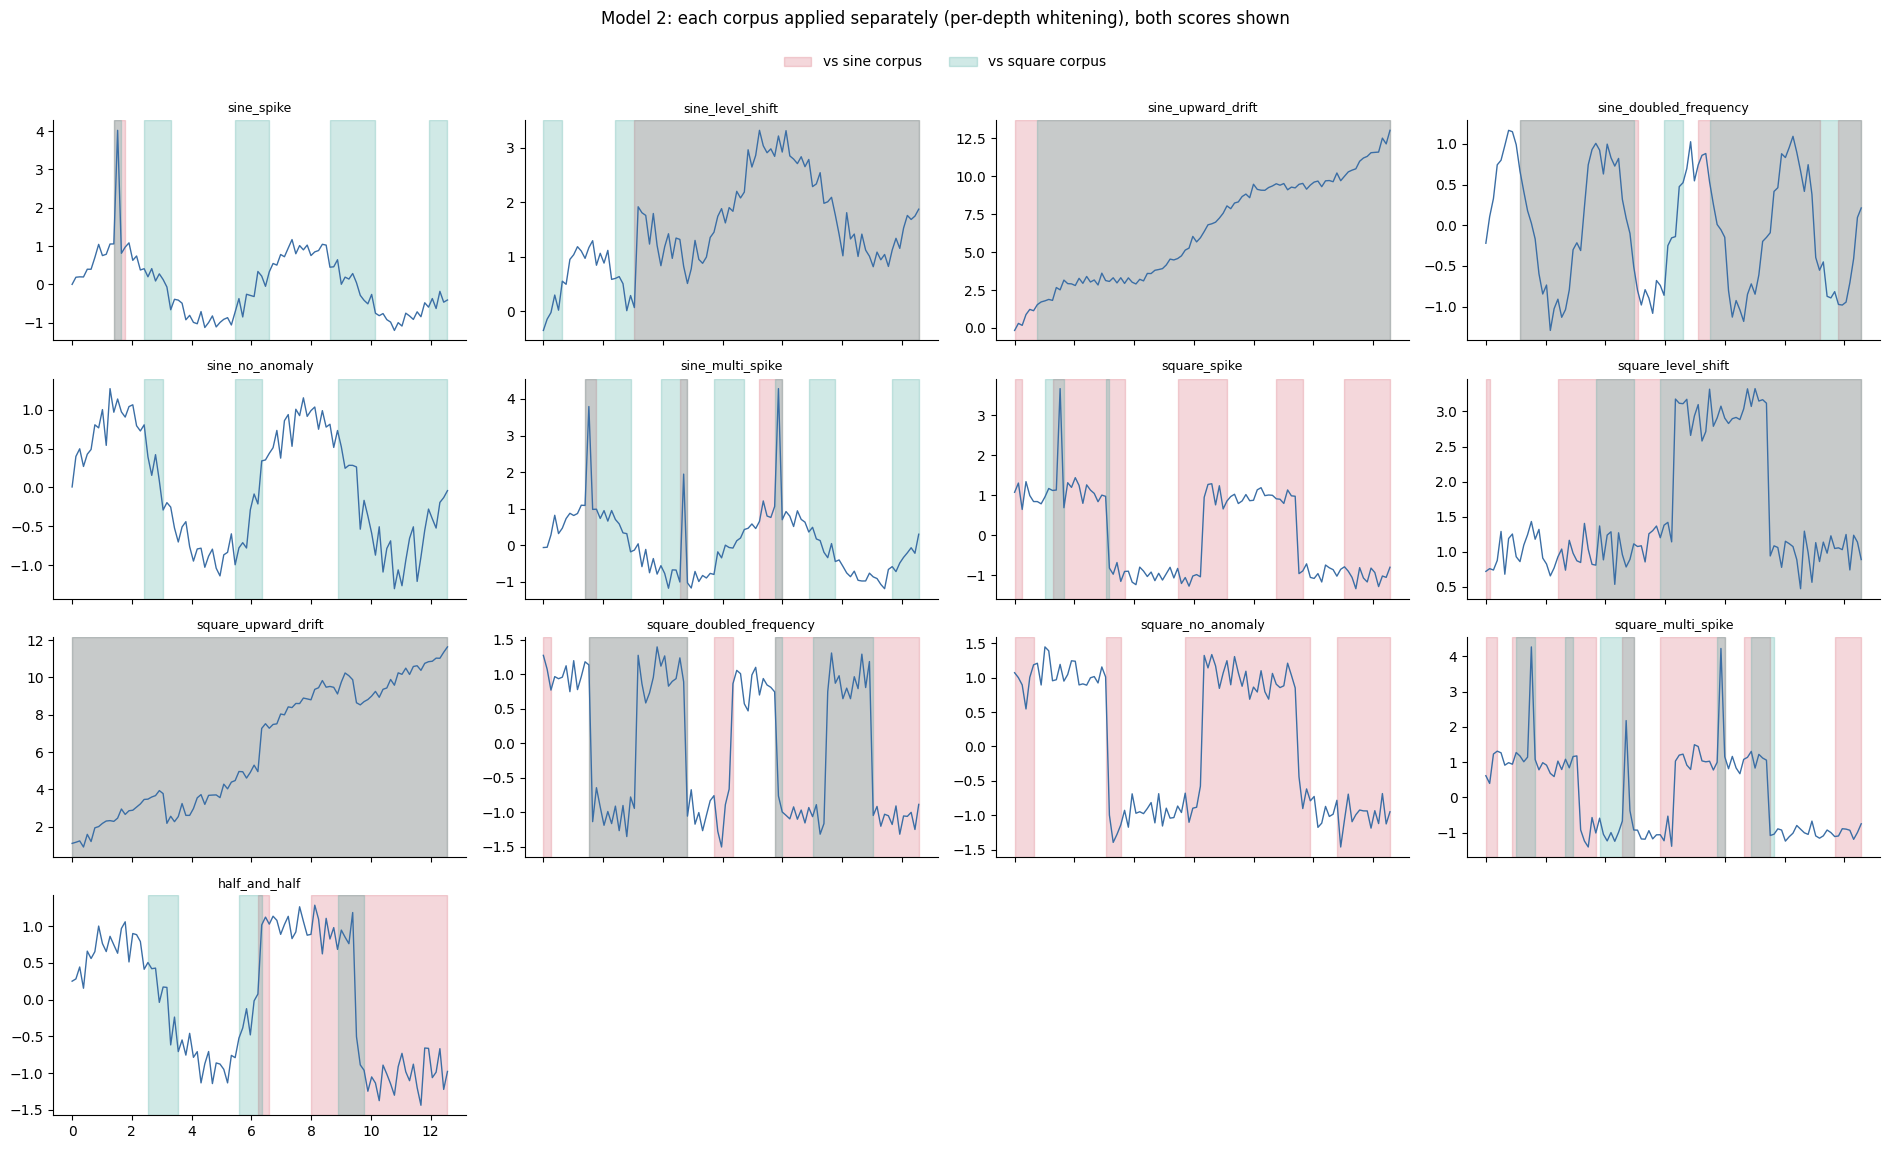

In [30]:
#=================================================================================================================================
# Comparing the two models across all 13 test streams
#=================================================================================================================================

configurations = [
    ('merged global',   results_merged_global),
    ('merged perdepth', results_merged_perdepth),
    ('sine global',     results_sine_global),
    ('sine perdepth',   results_sine_perdepth),
    ('square global',   results_square_global),
    ('square perdepth', results_square_perdepth),
]


def coverage(intervals):
    return sum(end - start for start, end in merge_intervals(intervals)) / (4 * np.pi) * 100


print('Percentage of each stream flagged anomalous\n')
print('{0:<26}'.format('stream') + ''.join('{0:>18}'.format(n) for n, _ in configurations))
print('-' * (26 + 18 * len(configurations)))
for name in multimodal_order:
    row = '{0:<26}'.format(name)
    for _label, results in configurations:
        row += '{0:>18}'.format('{0:5.1f}%'.format(coverage(results[name])))
    print(row)

# The two clean streams are the ones that say most about false positives.
print('\nClean streams (should ideally be flagged 0% by a corpus containing their own mode):')
for name in ('sine_no_anomaly', 'square_no_anomaly'):
    print('  {0}'.format(name))
    for label, results in configurations:
        print('    {0:<18} {1:5.1f}%  {2}'.format(
            label, coverage(results[name]), merge_intervals(results[name]) or '-'))

print('\nThe mode-switch stream (switch occurs at t = 2*pi = {0:.2f}):'.format(2 * np.pi))
for label, results in configurations:
    print('  {0:<18} {1}'.format(label, merge_intervals(results['half_and_half']) or '-'))


# --- Model 1: what the merged corpus flags -------------------------------------------
def panel_grid(results_by_label, title):
    fig, axes = plt.subplots(4, 4, figsize=(19, 11), sharex=True)
    flat = axes.ravel()
    palette = ['#d1495b', '#2a9d8f']

    for ax, name in zip(flat, multimodal_order):
        s = multimodal_tests[multimodal_tests['stream'] == name]
        ax.plot(s['time'].to_numpy(), s['output'].to_numpy(),
                color=line_color, linewidth=1.0)
        for offset, (label, results) in enumerate(results_by_label):
            for j, (start, end) in enumerate(merge_intervals(results[name])):
                ax.axvspan(start, end, color=palette[offset], alpha=0.22,
                           label=label if j == 0 else None)
        ax.set_title(name, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

    for ax in flat[len(multimodal_order):]:
        ax.axis('off')

    handles, labels = flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
                   bbox_to_anchor=(0.5, 1.01))
    fig.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()


panel_grid([('merged corpus', results_merged_perdepth)],
           'Model 1: one merged corpus (per-depth whitening)')

panel_grid([('vs sine corpus', results_sine_perdepth),
            ('vs square corpus', results_square_perdepth)],
           'Model 2: each corpus applied separately (per-depth whitening), both scores shown')

**The merged corpus handles bimodality cleanly, and that is not a foregone conclusion.**

## Model 1 accepts both modes; single-mode corpora reject the other one

The two clean streams are the test that matters, and the merged corpus passes it outright:

| clean stream | merged | vs sine corpus | vs square corpus |
|---|---|---|---|
| `sine_no_anomaly` | **0.0%** | 0.0% | 25.3% / 41.4% |
| `square_no_anomaly` | **0.0%** | 36.4% / 56.6% | 0.0% |

Zero false positives on both, under both whitening modes. The single-mode corpora reject the other mode heavily and symmetrically — a clean square wave is 36–57% "anomalous" to a sine corpus, and a clean sine is 25–41% anomalous to a square one. That symmetry is worth noting on its own: it confirms the two corpora are genuinely doing their jobs, so the merged corpus's zeros are a real result rather than a threshold that has gone slack.

This is the case where nearest-neighbour scoring should beat anything that models the corpus as one distribution, and it does. The merged corpus's *mean* now sits halfway between a sine and a square and describes neither, and the Mahalanobis whitening in front of the search is still fitted as a single Gaussian over both modes — yet detection is unaffected, because the kNN step only ever asks "is there something in the corpus close to this?", and for either mode there are 5,000 close things. The whitening being a poor description of the pooled distribution turns out not to matter when the decision rule is local.

## The mode-switch stream is the sharpest result

The switch sits at `t = 2*pi = 6.283`. Model 1 with global whitening flags **exactly one interval: (6.220, 6.347)** — 1.0% of the stream, bracketing the switch and nothing else.

That is the behaviour the multimodal setup was built to produce. Each half is individually unremarkable to a corpus containing both modes, so the only thing left to detect is the join, and that is precisely what comes back. No other configuration manages it:

```
merged global      (6.220, 6.347)                                    <- the switch, alone
merged perdepth    (6.220, 6.347), (8.505, 9.647)                    <- switch + one spurious
sine global        (6.220, 6.347), (9.266, 10.028), (11.932, 12.566) <- switch + square half
sine perdepth      (6.220, 6.601), (7.997, 12.566)                   <- switch + square half
square global      (2.666, 3.554)                                    <- misses the switch
square perdepth    (2.539, 3.554), (5.585, 6.347), (8.885, 9.774)    <- sine half + switch
```

The single-mode corpora do something reasonable but different: they flag the half that isn't theirs. That is correct behaviour for what they were asked, and it is exactly why they cannot isolate the transition — to a sine corpus the whole second half is anomalous, so the switch has no special status.

Note also that `square global` **misses the switch entirely**, flagging only part of the sine half. Whatever it finds unusual about (2.67, 3.55) it finds more unusual than a sine-to-square discontinuity.

## Merging costs little, but not nothing

Within-mode detection survives the merge almost intact. `sine_spike` is 2.0% merged against 3.0% sine-only; `square_spike` 2.0/5.1% merged against 2.0/6.1% square-only; the `multi_spike` and `level_shift` variants are comparable throughout. Doubling the corpus's diversity did not blunt it.

The exception is `doubled_frequency`, the notebook's perennial hard case: `sine_doubled_frequency` drops from 66.7/69.7% against the sine corpus to 59.6/56.6% merged. That is the expected direction — a doubled-frequency sine is closer to a square wave than a plain sine is, so adding square-wave neighbours gives it somewhere to hide. Small, but it is the one real cost of merging visible here.

## Which model to prefer depends on the question

| | Model 1 (merged) | Model 2 (separate) |
|---|---|---|
| answers per stream | 1 | 2 |
| total runtime | 98.0s (2 configs) | 126.2s (4 runs) |
| clean streams | 0% both | cross-mode false positives by design |
| isolates the mode switch | yes | no |
| identifies *which* mode | no | yes |

Model 2 costs about 30% more here — its corpora are half the size, so each run is cheaper (~31s against ~49s), but it needs two runs per answer. What it buys is the thing Model 1 structurally cannot provide: the merged corpus can say "this looks like something in the reference set", never "this looks like a square wave and not a sine". If mode identity is diagnostic — and for RFI-style work it usually is — that distinction is worth more than the runtime.

The practical combination is probably both: Model 1 as the detector, Model 2 as the explainer, run only on the intervals Model 1 flags.

## A refinement to the Section 6 timing conclusion

Sections 6a and 6b showed a consistent ~20% advantage for per-depth whitening (49.7 vs 40.1, then 48.4 vs 39.7). On the merged corpus that gap nearly disappears: **49.6s global against 48.4s per-depth**, a 2.4% difference.

The explanation is that 6a's penalty is a *fixed* cost, not a per-query one. Its single global fit must fold in all 1.97M pooled rows, while per-depth fits touch only the ~630k rows belonging to depths the search actually visits. Spread across 6 test streams that one-off dominates; spread across 13 it is amortized to near-irrelevance. So the Section 6 conclusion should be read as "global whitening has a larger start-up cost", not "global whitening is slower per query" — and the more streams a reference is reused for, the less it matters.

## Caveats

Coverage percentage is still not a proper accuracy metric: it rewards flagging the right *amount* rather than the right *place*, and only the mode-switch stream was examined interval by interval. The labelled ground-truth harness proposed earlier would settle several of the judgements above that currently rest on reading spans. The `no_anomaly` results are the exception — 0% is unambiguous however it is measured, and they are the strongest evidence in this section.